<a href="https://colab.research.google.com/github/sl007ha/qqq-risk-monitor/blob/main/notebooks/06c_walkforward_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
!pip install yfinance fredapi --quiet

import pandas as pd
import numpy as np
import yfinance as yf
from fredapi import Fred
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import brier_score_loss, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
from google.colab import userdata

fred = Fred(api_key=userdata.get('FRED_API_KEY'))

# 拉之前 notebook 准备好的 csv（现在 Colab 里可能已经丢了，重新生成或上传）
# 简化做法：把这个 notebook 写成自包含的，从头拉所有数据

# ===== 1. NDX 价格 =====
ndx_d = yf.download('^NDX', start='1985-01-01', end='2025-12-31', auto_adjust=True)
ndx_d = ndx_d[['Close']].copy()
ndx_d.columns = ['ndx_close']
ndx_d['ma200'] = ndx_d['ndx_close'].rolling(200).mean()
ndx_d['dist_200dma'] = (ndx_d['ndx_close'] / ndx_d['ma200']) - 1

ndx_m = ndx_d[['ndx_close']].resample('ME').last()
ndx_m['tsmom_12m'] = ndx_m['ndx_close'].pct_change(12)
ndx_m['dist_200dma'] = ndx_d['dist_200dma'].resample('ME').last()

# ===== 2. CAPE（用 2.1 的代码） =====
import requests, io
SHILLER_URL = "https://img1.wsimg.com/blobby/go/e5e77e0b-59d1-44d9-ab25-4763ac982e53/downloads/441f0d2c-37e4-4803-b4e2-8fe10407fbf6/ie_data.xls?ver=1778098504874"
response = requests.get(SHILLER_URL, timeout=30)
shiller = pd.read_excel(io.BytesIO(response.content), sheet_name='Data', skiprows=7)
shiller = shiller.dropna(subset=['Date'])
shiller = shiller[shiller['Date'].apply(lambda x: isinstance(x, (int, float)))]

def shiller_date_to_ts(d):
    year = int(d)
    month = round((d - year) * 100)
    if month == 0:
        month = 1
    return pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd(0)

shiller['date'] = shiller['Date'].apply(shiller_date_to_ts)
shiller = shiller.set_index('date')

cape_df = shiller[['CAPE']].copy()
cape_df.columns = ['cape']
cape_df = cape_df.dropna()

window = 240
cape_df['cape_z'] = (cape_df['cape'] - cape_df['cape'].rolling(window, min_periods=120).mean()) / cape_df['cape'].rolling(window, min_periods=120).std()

# ===== 3. 收益率曲线 =====
yc = fred.get_series('T10Y3M', observation_start='1985-01-01').resample('ME').last().to_frame('yc_10y3m')

# ===== 4. CFNAI =====
cfnai = fred.get_series('CFNAIMA3', observation_start='1985-01-01').resample('ME').last().to_frame('cfnai_ma3')

# ===== 5. AAII（你需要先把 sentiment.xls 上传到 /content/） =====
import os
if os.path.exists('/content/sentiment.xls'):
    aaii_raw = pd.read_excel('/content/sentiment.xls', sheet_name=0, skiprows=3)
    # ... 用 2.3.3 的清洗代码处理 ...
    # 简化：假设你已经把 aaii.csv 也上传了
    aaii_m = pd.read_csv('/content/aaii.csv', index_col=0, parse_dates=True)
else:
    print("⚠️ aaii.csv 没找到，AAII 特征会缺失。先把 2.3 的输出上传到 /content/aaii.csv")
    aaii_m = pd.DataFrame(index=ndx_m.index, columns=['bb_spread'])

# ===== 6. 合并 =====
features_v2 = pd.DataFrame(index=ndx_m.index)
features_v2['cape_z'] = cape_df['cape_z']
features_v2['dist_200dma'] = ndx_m['dist_200dma']
features_v2['tsmom_12m'] = ndx_m['tsmom_12m']
features_v2['yc_10y3m'] = yc['yc_10y3m']
features_v2['cfnai_ma3'] = cfnai['cfnai_ma3']
features_v2['bb_spread'] = aaii_m['bb_spread']

# 看缺失情况
print(features_v2.isna().sum())
print(features_v2.dropna().index.min(), '->', features_v2.dropna().index.max())

[*********************100%***********************]  1 of 1 completed


cape_z          0
dist_200dma     9
tsmom_12m      12
yc_10y3m        0
cfnai_ma3       0
bb_spread      21
dtype: int64
1987-07-31 00:00:00 -> 2025-12-31 00:00:00


In [32]:
def future_max_drawdown(prices, current_idx, horizon_days=126):
    if current_idx + horizon_days >= len(prices):
        return np.nan
    future_prices = prices.iloc[current_idx : current_idx + horizon_days + 1]
    running_max = future_prices.cummax()
    drawdown = (future_prices / running_max) - 1
    return drawdown.min()

month_ends = ndx_d.resample('ME').last().index
labels = []
for d in month_ends:
    if (ndx_d.index <= d).any():
        d_actual = ndx_d.index[ndx_d.index <= d][-1]
    else:
        labels.append((d, np.nan)); continue
    idx = ndx_d.index.get_loc(d_actual)
    mdd = future_max_drawdown(ndx_d['ndx_close'], idx)
    labels.append((d, mdd))

# ===== 重新生成 labels_df：保留 future_6m_mdd 的 NaN =====

labels_df = pd.DataFrame(labels, columns=['date', 'future_6m_mdd']).set_index('date')

# 关键修复：
# 如果 future_6m_mdd 是 NaN，label_15 也必须是 NaN，不能被转成 0
labels_df['label_15'] = np.where(
    labels_df['future_6m_mdd'].isna(),
    np.nan,
    (labels_df['future_6m_mdd'] <= -0.15).astype(int)
)

print("Label check:")
print(labels_df.tail(12))
print("\nMissing future_6m_mdd:", labels_df['future_6m_mdd'].isna().sum())
print("Missing label_15:", labels_df['label_15'].isna().sum())


# ===== 重新合并 df_v2 =====

df_v2_full = features_v2.join(labels_df[['future_6m_mdd', 'label_15']], how='inner')

print("\nBefore dropna:")
print("Rows:", len(df_v2_full))
print("Last rows before dropna:")
print(df_v2_full.tail(12))

# 建模用 df_v2：特征和 label 都必须完整
feature_cols = [c for c in features_v2.columns]

df_v2 = df_v2_full.dropna(subset=feature_cols + ['label_15']).copy()

# label 转成 int，方便后面模型使用
df_v2['label_15'] = df_v2['label_15'].astype(int)

print("\nAfter dropna:")
print(f"v2 训练用样本数：{len(df_v2)}")
print(f"起始：{df_v2.index.min()}，终止：{df_v2.index.max()}")
print(f"label_15 分布：{df_v2['label_15'].value_counts().to_dict()}")
print(f"base rate：{df_v2['label_15'].mean():.2%}")

print("\nLast valid rows:")
print(df_v2.tail(12)[['future_6m_mdd', 'label_15']])
print(f"v2 训练用样本数：{len(df_v2)}")
print(f"起始：{df_v2.index.min()}，终止：{df_v2.index.max()}")
print(f"label_15 分布：{df_v2['label_15'].value_counts().to_dict()}")

Label check:
            future_6m_mdd  label_15
date                               
2025-01-31      -0.229315       1.0
2025-02-28      -0.181667       1.0
2025-03-31      -0.127229       0.0
2025-04-30      -0.036396       0.0
2025-05-31      -0.079077       0.0
2025-06-30      -0.079077       0.0
2025-07-31            NaN       NaN
2025-08-31            NaN       NaN
2025-09-30            NaN       NaN
2025-10-31            NaN       NaN
2025-11-30            NaN       NaN
2025-12-31            NaN       NaN

Missing future_6m_mdd: 6
Missing label_15: 6

Before dropna:
Rows: 483
Last rows before dropna:
              cape_z  dist_200dma  tsmom_12m  yc_10y3m  cfnai_ma3  bb_spread  \
Date                                                                           
2025-01-31  2.003601     0.083256   0.253297      0.27      -0.08     6.9278   
2025-02-28  1.989633     0.033861   0.157425     -0.08       0.07   -41.2308   
2025-03-31  1.515906    -0.051083   0.056082     -0.09       0.02 

In [33]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, roc_auc_score, average_precision_score

def walk_forward_v3(
    df,
    embargo_months=6,
    train_min_samples=60,
    train_min_positives=5,
    oos_start='2005-01-01',
    winsorize_quantiles=(0.01, 0.99),
    use_calibration=True,
    calibration_window_months=60,
):
    """
    修订版 walk-forward，主要变化：
    1. OOS 段从 oos_start 开始（避免 1990s 早期不稳定数据）
    2. 不使用 class_weight='balanced'
    3. 集成 isotonic 校准（用 cutoff 之前最近 calibration_window_months 个月作为 calibration set）
    4. 特征 winsorize（用 cutoff 之前数据估计分位）
    """
    results = []
    all_dates = sorted(df.index.tolist())
    oos_start_ts = pd.Timestamp(oos_start)

    for i, cutoff in enumerate(all_dates):
        # 只在 oos_start 之后才输出预测
        if cutoff < oos_start_ts:
            continue

        cutoff_train_end = cutoff - pd.DateOffset(months=embargo_months)
        train_part_full = df[df.index < cutoff_train_end].copy()
        test_part = df[df.index == cutoff].copy()

        if len(train_part_full) < train_min_samples + calibration_window_months:
            continue
        if train_part_full['label_15'].sum() < train_min_positives:
            continue
        if len(test_part) == 0:
            continue

        # ===== 1. Winsorize：用 cutoff_train_end 之前数据估计分位 =====
        feature_cols = [c for c in df.columns if c != 'label_15']
        lo_q, hi_q = winsorize_quantiles
        bounds = {}
        for col in feature_cols:
            bounds[col] = (
                train_part_full[col].quantile(lo_q),
                train_part_full[col].quantile(hi_q)
            )

        train_part = train_part_full.copy()
        for col in feature_cols:
            lo, hi = bounds[col]
            train_part[col] = train_part[col].clip(lo, hi)
            test_part[col] = test_part[col].clip(lo, hi)

        # ===== 2. 切分 train / calibration =====
        if use_calibration:
            train_for_fit = train_part.iloc[:-calibration_window_months]
            calib = train_part.iloc[-calibration_window_months:]
        else:
            train_for_fit = train_part
            calib = None

        if train_for_fit['label_15'].sum() < train_min_positives:
            continue

        # ===== 3. 训练（不用 class_weight='balanced'） =====
        X_tr = train_for_fit[feature_cols]
        y_tr = train_for_fit['label_15']
        sc = StandardScaler().fit(X_tr)
        m = LogisticRegression(C=1.0, max_iter=1000, random_state=42).fit(sc.transform(X_tr), y_tr)

        # ===== 4. 在 calibration set 上拟合 isotonic =====
        if use_calibration and calib is not None and calib['label_15'].nunique() > 1:
            X_cal = calib[feature_cols]
            y_cal = calib['label_15']
            p_cal_raw = m.predict_proba(sc.transform(X_cal))[:, 1]
            iso = IsotonicRegression(out_of_bounds='clip').fit(p_cal_raw, y_cal)

            # 测试集预测
            X_te = test_part[feature_cols]
            p_te_raw = m.predict_proba(sc.transform(X_te))[:, 1]
            p_te = iso.predict(p_te_raw)[0]
        else:
            X_te = test_part[feature_cols]
            p_te = m.predict_proba(sc.transform(X_te))[0, 1]

        results.append({
            'date': cutoff,
            'p_15': float(p_te),
            'label': int(test_part['label_15'].iloc[0]),
        })

    return pd.DataFrame(results).set_index('date')

# 跑！
wf_v3 = walk_forward_v3(df_v2, oos_start='2005-01-01')
print(f"Walk-forward v3 输出 {len(wf_v3)} 行")
print(wf_v3.head())
print(wf_v3.tail())

Walk-forward v3 输出 246 行
            p_15  label
date                   
2005-01-31   0.0      0
2005-02-28   0.0      0
2005-03-31   0.0      0
2005-04-30   0.0      0
2005-05-31   0.0      0
            p_15  label
date                   
2025-02-28   1.0      1
2025-03-31   0.0      0
2025-04-30   0.0      0
2025-05-31   0.0      0
2025-06-30   0.0      0


In [34]:
def evaluate(wf_df, label_col='label', proba_col='p_15'):
    sub = wf_df.dropna()
    if len(sub) < 10 or sub[label_col].nunique() < 2:
        return None
    return {
        'n': len(sub),
        'brier': brier_score_loss(sub[label_col], sub[proba_col]),
        'baseline_brier': brier_score_loss(sub[label_col], [sub[label_col].mean()] * len(sub)),
        'auc': roc_auc_score(sub[label_col], sub[proba_col]),
        'pr_auc': average_precision_score(sub[label_col], sub[proba_col]),
        'base_rate': sub[label_col].mean(),
    }

periods = {
    'all_oos': (None, None),
    '2005–2010 (含 GFC)': ('2005-01', '2010-12'),
    '2007–2009 (GFC 核心)': ('2007-01', '2009-12'),
    '2015–2026 (近期)': ('2015-01', '2026-12'),
    '2020 (COVID 段)': ('2019-09', '2020-12'),
    '2022 (科技熊)': ('2021-09', '2022-12'),
}

print(f"{'Period':<25} {'N':<5} {'Brier':<8} {'Base':<8} {'AUC':<7} {'PR-AUC':<8} {'BaseRate':<8}")
print('-' * 80)
for name, (start, end) in periods.items():
    sub = wf_v3.copy()
    if start: sub = sub[sub.index >= start]
    if end: sub = sub[sub.index <= end]
    m = evaluate(sub)
    if m is None:
        print(f"{name:<25} (insufficient data)")
        continue
    print(f"{name:<25} {m['n']:<5} {m['brier']:<8.4f} {m['baseline_brier']:<8.4f} {m['auc']:<7.3f} {m['pr_auc']:<8.3f} {m['base_rate']:<8.3f}")

Period                    N     Brier    Base     AUC     PR-AUC   BaseRate
--------------------------------------------------------------------------------
all_oos                   246   0.0456   0.1944   0.946   0.865    0.264   
2005–2010 (含 GFC)         71    0.0704   0.2281   0.900   0.870    0.352   
2007–2009 (GFC 核心)        35    0.0000   0.2498   1.000   1.000    0.486   
2015–2026 (近期)            126   0.0451   0.2006   0.972   0.872    0.278   
2020 (COVID 段)            15    0.0000   0.2400   1.000   1.000    0.400   
2022 (科技熊)                15    0.0000   0.1600   1.000   1.000    0.800   


/tmp/ipykernel_4223/166413902.py:32: UserWarning: Glyph 31185 (\N{CJK UNIFIED IDEOGRAPH-79D1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4223/166413902.py:32: UserWarning: Glyph 25216 (\N{CJK UNIFIED IDEOGRAPH-6280}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4223/166413902.py:32: UserWarning: Glyph 29066 (\N{CJK UNIFIED IDEOGRAPH-718A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4223/166413902.py:33: UserWarning: Glyph 31185 (\N{CJK UNIFIED IDEOGRAPH-79D1}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/crashes_v3.png', dpi=100)
/tmp/ipykernel_4223/166413902.py:33: UserWarning: Glyph 25216 (\N{CJK UNIFIED IDEOGRAPH-6280}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/crashes_v3.png', dpi=100)
/tmp/ipykernel_4223/166413902.py:33: UserWarning: Glyph 29066 (\N{CJK UNIFIED IDEOGRAPH-718A}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/crashes_v3.png', dpi=100)
/usr/local/li

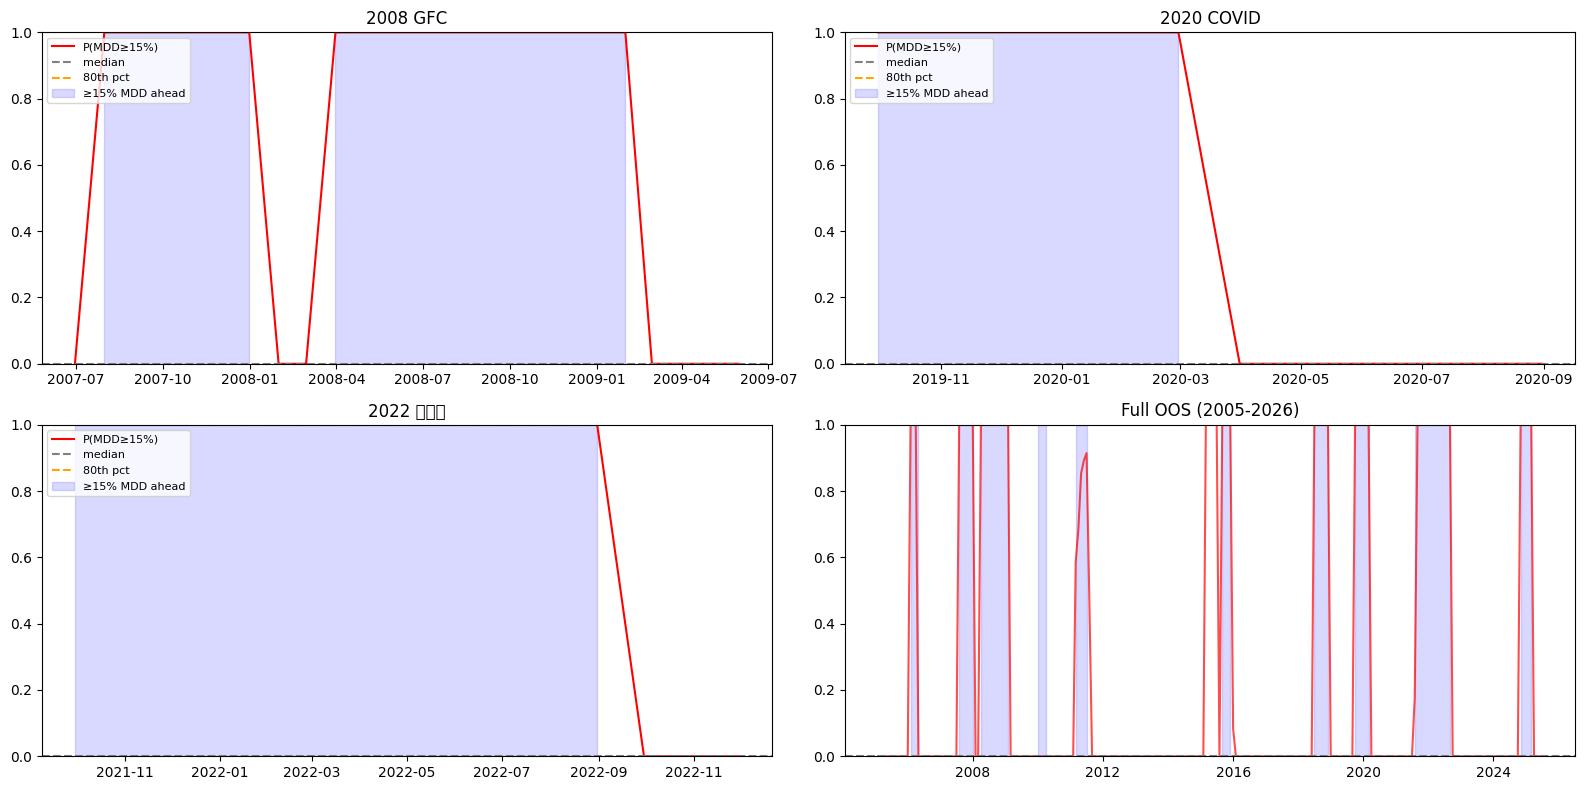

In [35]:
import matplotlib.pyplot as plt

crashes = {
    '2008 GFC':     ('2007-06-01', '2009-06-01'),
    '2020 COVID':   ('2019-09-01', '2020-09-01'),
    '2022 科技熊':   ('2021-09-01', '2022-12-01'),
    # 注意：dot-com 这次不在 OOS 里（因为 oos_start=2005），所以这张图不放
}

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
# 左下放一个空图占位，或者放一个全样本概率图

for ax, (name, (start, end)) in zip(axes.flat[:3], crashes.items()):
    sub = wf_v3[(wf_v3.index >= start) & (wf_v3.index <= end)]
    ax.plot(sub.index, sub['p_15'], color='red', label='P(MDD≥15%)')
    ax.axhline(wf_v3['p_15'].quantile(0.5), color='gray', linestyle='--', label='median')
    ax.axhline(wf_v3['p_15'].quantile(0.8), color='orange', linestyle='--', label='80th pct')
    ax.fill_between(sub.index, 0, 1, where=sub['label']==1, alpha=0.15, color='blue', label='≥15% MDD ahead')
    ax.set_title(name)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper left', fontsize=8)

# 第 4 张图：全 OOS 段的概率
ax = axes.flat[3]
ax.plot(wf_v3.index, wf_v3['p_15'], color='red', alpha=0.7)
ax.axhline(wf_v3['p_15'].quantile(0.5), color='gray', linestyle='--')
ax.axhline(wf_v3['p_15'].quantile(0.8), color='orange', linestyle='--')
ax.fill_between(wf_v3.index, 0, 1, where=wf_v3['label']==1, alpha=0.15, color='blue')
ax.set_title('Full OOS (2005-2026)')
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('/content/crashes_v3.png', dpi=100)
plt.show()

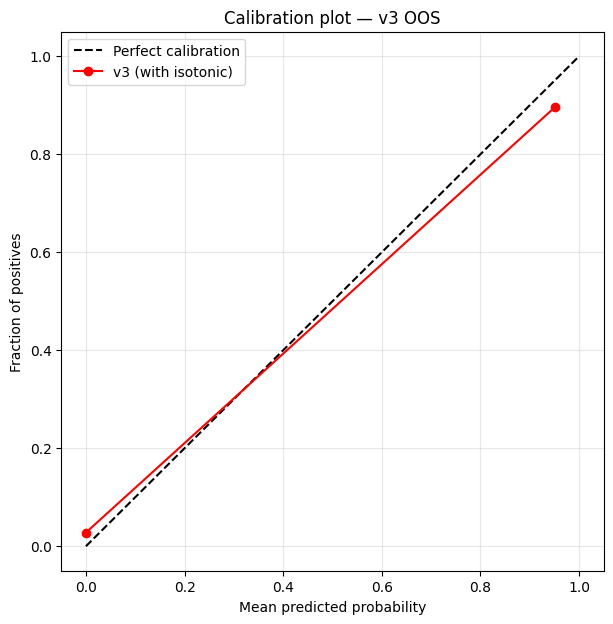

In [36]:
from sklearn.calibration import calibration_curve

oos = wf_v3.dropna()

# 把概率分成 10 个 bin，看每个 bin 内的预测概率均值 vs 实际频率
prob_true, prob_pred = calibration_curve(oos['label'], oos['p_15'], n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(prob_pred, prob_true, 'o-', color='red', label='v3 (with isotonic)')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration plot — v3 OOS')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [37]:
import numpy as np
import pandas as pd

from sklearn.metrics import brier_score_loss, roc_auc_score, average_precision_score

# ===== 0. 准备 OOS 数据 =====
oos = wf_v3.dropna().copy()

# 确保 index 是 Timestamp
oos.index = pd.to_datetime(oos.index)
df_tmp = df_v2.copy()
df_tmp.index = pd.to_datetime(df_tmp.index)

label_col = 'label'
proba_col = 'p_15'

def safe_metrics(y, p):
    y = pd.Series(y).astype(int)
    p = pd.Series(p).astype(float)

    out = {
        'n': len(y),
        'base_rate': y.mean(),
        'brier': brier_score_loss(y, p),
        'baseline_brier_const': brier_score_loss(y, [y.mean()] * len(y)),
        'auc': np.nan,
        'pr_auc': np.nan,
        'p_mean': p.mean(),
        'p_std': p.std(),
        'p_min': p.min(),
        'p_max': p.max(),
    }

    if y.nunique() > 1:
        out['auc'] = roc_auc_score(y, p)
        out['pr_auc'] = average_precision_score(y, p)

    return out


# ===== 1. 构造几个极简 baseline =====
# 注意：为了避免 label 泄漏，每个月只能用 cutoff - 6个月以前已经完整知道的 label
def expanding_base_rate(date):
    hist = df_tmp[df_tmp.index < date - pd.DateOffset(months=6)]
    if len(hist) == 0:
        return np.nan
    return hist['label_15'].mean()

def rolling_base_rate(date, months=120):
    end = date - pd.DateOffset(months=6)
    start = end - pd.DateOffset(months=months)
    hist = df_tmp[(df_tmp.index >= start) & (df_tmp.index < end)]
    if len(hist) == 0:
        return np.nan
    return hist['label_15'].mean()

def known_lag_label(date, lag_months=6):
    # date 当月预测时，date-6 的未来6个月窗口刚刚基本已知
    target_date = date - pd.DateOffset(months=lag_months)
    hist = df_tmp[df_tmp.index <= target_date]
    if len(hist) == 0:
        return np.nan
    return hist['label_15'].iloc[-1]

oos['p_expanding_base'] = [expanding_base_rate(d) for d in oos.index]
oos['p_10y_rolling_base'] = [rolling_base_rate(d, 120) for d in oos.index]
oos['p_5y_rolling_base'] = [rolling_base_rate(d, 60) for d in oos.index]
oos['p_known_lag6_label'] = [known_lag_label(d, 6) for d in oos.index]


# ===== 2. 比较 v3 和极简 baseline =====
models = {
    'v3_model': 'p_15',
    'expanding_base': 'p_expanding_base',
    '10y_rolling_base': 'p_10y_rolling_base',
    '5y_rolling_base': 'p_5y_rolling_base',
    'known_lag6_label': 'p_known_lag6_label',
}

rows = []

for name, col in models.items():
    sub = oos[[label_col, col]].dropna()
    m = safe_metrics(sub[label_col], sub[col])
    m['model'] = name
    rows.append(m)

summary = pd.DataFrame(rows).set_index('model')
cols = ['n', 'base_rate', 'brier', 'baseline_brier_const', 'auc', 'pr_auc', 'p_mean', 'p_std', 'p_min', 'p_max']
print(summary[cols].round(4))


# ===== 3. label 自相关与有效样本数 =====
y = oos[label_col].astype(int)

print("\nLabel autocorrelation:")
for lag in range(1, 13):
    ac = y.autocorr(lag)
    print(f"lag {lag:2d}: {ac:.3f}")

# 粗略 effective sample size
# N_eff ≈ N / (1 + 2 * sum positive autocorr)
acs = []
for lag in range(1, 13):
    ac = y.autocorr(lag)
    if pd.notna(ac) and ac > 0:
        acs.append(ac)

n_eff = len(y) / (1 + 2 * np.sum(acs))
print(f"\nNominal N = {len(y)}")
print(f"Approx effective N = {n_eff:.1f}")


# ===== 4. 正样本 cluster 统计 =====
cluster_id = ((y != y.shift(1)) & (y == 1)).cumsum()
positive_clusters = y[y == 1].groupby(cluster_id[y == 1]).size()

print("\nPositive label clusters:")
print(f"number of positive clusters = {len(positive_clusters)}")
print(f"cluster lengths = {positive_clusters.tolist()}")
print(f"mean cluster length = {positive_clusters.mean():.2f}")


# ===== 5. v3 概率分布诊断 =====
p = oos['p_15']

print("\nv3 probability distribution:")
print(p.describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).round(4))

print("\nExtreme probability counts:")
print(f"p == 0: {(p == 0).sum()}")
print(f"p == 1: {(p == 1).sum()}")
print(f"p < 0.05: {(p < 0.05).sum()}")
print(f"p > 0.95: {(p > 0.95).sum()}")
print(f"unique p values: {p.nunique()}")

                    n  base_rate   brier  baseline_brier_const     auc  \
model                                                                    
v3_model          246     0.2642  0.0456                0.1944  0.9459   
expanding_base    246     0.2642  0.2013                0.1944  0.3816   
10y_rolling_base  246     0.2642  0.2073                0.1944  0.4604   
5y_rolling_base   246     0.2642  0.2374                0.1944  0.3909   
known_lag6_label  246     0.2642  0.3902                0.1944  0.4932   

                  pr_auc  p_mean   p_std   p_min   p_max  
model                                                     
v3_model          0.8654  0.2588  0.4331  0.0000  1.0000  
expanding_base    0.2179  0.3250  0.0227  0.2911  0.3668  
10y_rolling_base  0.2912  0.3066  0.1116  0.1333  0.4917  
5y_rolling_base   0.2169  0.2776  0.1409  0.0667  0.6333  
known_lag6_label  0.2617  0.2561  0.4374  0.0000  1.0000  

Label autocorrelation:
lag  1: 0.791
lag  2: 0.581
lag  3: 0.391
la

In [38]:
import numpy as np
import pandas as pd
from sklearn.metrics import brier_score_loss, roc_auc_score, average_precision_score

# ===== 0. 准备数据 =====
oos = wf_v3.dropna().copy()
oos.index = pd.to_datetime(oos.index)

df_tmp = df_v2.copy()
df_tmp.index = pd.to_datetime(df_tmp.index)

label_col = 'label'
p_col = 'p_15'

def safe_metrics(y, p):
    y = pd.Series(y).astype(int)
    p = pd.Series(p).astype(float)

    out = {
        'n': len(y),
        'base_rate': y.mean(),
        'brier': brier_score_loss(y, p),
        'baseline_brier_const': brier_score_loss(y, [y.mean()] * len(y)),
        'auc': np.nan,
        'pr_auc': np.nan,
        'p_mean': p.mean(),
        'p_std': p.std(),
        'p_min': p.min(),
        'p_max': p.max(),
    }

    if y.nunique() > 1:
        out['auc'] = roc_auc_score(y, p)
        out['pr_auc'] = average_precision_score(y, p)

    return out

def expanding_base_rate(date):
    # 避免 label leakage：只用 date - 6个月之前已经完整知道的 label
    hist = df_tmp[df_tmp.index < date - pd.DateOffset(months=6)]
    if len(hist) == 0:
        return np.nan
    return hist['label_15'].mean()

oos['p_expanding_base'] = [expanding_base_rate(d) for d in oos.index]

# ===== 1. 概率后处理函数 =====
def clip_prob(p, lo, hi):
    return np.clip(p, lo, hi)

def blend_with_prior(p, prior, alpha, lo=0.02, hi=0.80):
    """
    alpha = 1: 原模型
    alpha = 0: 完全使用 expanding prior
    """
    out = prior + alpha * (p - prior)
    return np.clip(out, lo, hi)

def logit(x):
    x = np.clip(x, 1e-4, 1 - 1e-4)
    return np.log(x / (1 - x))

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def logit_shrink_to_prior(p, prior, shrink, lo=0.02, hi=0.80):
    """
    把模型信号当成 log-odds deviation，
    shrink 越小，越相信长期先验；越大，越相信模型极端信号。
    """
    z = logit(prior) + shrink * logit(p)
    return np.clip(sigmoid(z), lo, hi)

# ===== 2. 生成候选概率 =====
p = oos[p_col].astype(float)
prior = oos['p_expanding_base'].astype(float)

candidates = {}

# 原始模型
candidates['v3_original'] = p

# 简单 clipping：只压掉 0 和 1 的极端概率
for lo, hi in [(0.01, 0.80), (0.02, 0.75), (0.05, 0.70), (0.05, 0.65), (0.10, 0.70)]:
    candidates[f'clip_{lo}_{hi}'] = clip_prob(p, lo, hi)

# 线性 shrink 到 expanding prior
for alpha in [0.25, 0.40, 0.50, 0.60, 0.75]:
    candidates[f'blend_prior_alpha_{alpha}'] = blend_with_prior(p, prior, alpha)

# logit shrink 到 expanding prior
for shrink in [0.10, 0.20, 0.30, 0.40, 0.50]:
    candidates[f'logit_shrink_{shrink}'] = logit_shrink_to_prior(p, prior, shrink)

# baseline
candidates['expanding_base'] = prior

# ===== 3. 评估 =====
rows = []
for name, prob in candidates.items():
    sub = pd.DataFrame({
        'y': oos[label_col].astype(int),
        'p': prob
    }).dropna()

    m = safe_metrics(sub['y'], sub['p'])
    m['model'] = name
    rows.append(m)

summary2 = pd.DataFrame(rows).set_index('model')
cols = ['n', 'base_rate', 'brier', 'baseline_brier_const', 'auc', 'pr_auc', 'p_mean', 'p_std', 'p_min', 'p_max']

print("=== Calibration shrinkage test: sorted by Brier ===")
print(summary2[cols].sort_values('brier').round(4))

print("\n=== Sorted by PR-AUC ===")
print(summary2[cols].sort_values('pr_auc', ascending=False).round(4).head(10))

# ===== 4. 看不同历史阶段表现 =====
periods = {
    'all_oos': (oos.index.min(), oos.index.max()),
    '2005_2010_GFC': ('2005-01-01', '2010-12-31'),
    '2011_2019_mid_cycle': ('2011-01-01', '2019-12-31'),
    '2020_COVID': ('2020-01-01', '2020-12-31'),
    '2022_tech_bear': ('2022-01-01', '2022-12-31'),
    '2023_2026_recent': ('2023-01-01', '2026-12-31'),
}

top_models = summary2.sort_values('brier').head(5).index.tolist()
period_rows = []

for period_name, (start, end) in periods.items():
    mask = (oos.index >= pd.to_datetime(start)) & (oos.index <= pd.to_datetime(end))
    for model_name in ['v3_original', 'expanding_base'] + top_models:
        if model_name not in candidates:
            continue

        sub = pd.DataFrame({
            'y': oos.loc[mask, label_col].astype(int),
            'p': pd.Series(candidates[model_name], index=oos.index).loc[mask]
        }).dropna()

        if len(sub) < 5:
            continue

        m = safe_metrics(sub['y'], sub['p'])
        m['period'] = period_name
        m['model'] = model_name
        period_rows.append(m)

period_summary = pd.DataFrame(period_rows).set_index(['period', 'model'])

print("\n=== Period breakdown for best Brier candidates ===")
print(period_summary[['n', 'base_rate', 'brier', 'auc', 'pr_auc', 'p_mean', 'p_min', 'p_max']].round(4))

=== Calibration shrinkage test: sorted by Brier ===
                          n  base_rate   brier  baseline_brier_const     auc  \
model                                                                          
v3_original             246     0.2642  0.0456                0.1944  0.9459   
clip_0.01_0.8           246     0.2642  0.0471                0.1944  0.9466   
blend_prior_alpha_0.75  246     0.2642  0.0491                0.1944  0.9720   
logit_shrink_0.5        246     0.2642  0.0495                0.1944  0.9459   
logit_shrink_0.4        246     0.2642  0.0501                0.1944  0.9459   
logit_shrink_0.3        246     0.2642  0.0505                0.1944  0.9720   
clip_0.02_0.75          246     0.2642  0.0505                0.1944  0.9466   
clip_0.05_0.7           246     0.2642  0.0557                0.1944  0.9466   
logit_shrink_0.2        246     0.2642  0.0566                0.1944  0.9691   
clip_0.1_0.7            246     0.2642  0.0592                0.1944

In [39]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, roc_auc_score, average_precision_score

def walk_forward_v3_debug(
    df,
    embargo_months=6,
    train_min_samples=60,
    train_min_positives=5,
    oos_start='2005-01-01',
    winsorize_quantiles=(0.01, 0.99),
    use_calibration=True,
    calibration_window_months=60,
):
    results = []
    all_dates = sorted(df.index.tolist())
    oos_start_ts = pd.Timestamp(oos_start)

    for cutoff in all_dates:
        if cutoff < oos_start_ts:
            continue

        cutoff_train_end = cutoff - pd.DateOffset(months=embargo_months)

        train_part_full = df[df.index < cutoff_train_end].copy()
        test_part = df[df.index == cutoff].copy()

        if len(train_part_full) < train_min_samples + calibration_window_months:
            continue

        if train_part_full['label_15'].sum() < train_min_positives:
            continue

        if len(test_part) == 0:
            continue

        # ===== feature columns: 必须排除 label 和未来信息 =====
        forbidden_cols = ['label_15', 'future_6m_mdd']

        feature_cols = [
            c for c in df.columns
            if c not in forbidden_cols
        ]

        # 防止未来再误把标签/未来变量放进模型
        for forbidden_col in forbidden_cols:
            assert forbidden_col not in feature_cols, f"Leakage detected: {forbidden_col} is in feature_cols"

        print("Model feature columns:", feature_cols)


        # ===== 1. walk-forward 内部 winsorize =====
        lo_q, hi_q = winsorize_quantiles
        bounds = {}

        for col in feature_cols:
            bounds[col] = (
                train_part_full[col].quantile(lo_q),
                train_part_full[col].quantile(hi_q)
            )

        train_part = train_part_full.copy()

        for col in feature_cols:
            lo, hi = bounds[col]
            train_part[col] = train_part[col].clip(lo, hi)
            test_part[col] = test_part[col].clip(lo, hi)

        # ===== 2. train / calibration split =====
        if use_calibration:
            train_for_fit = train_part.iloc[:-calibration_window_months]
            calib = train_part.iloc[-calibration_window_months:]
        else:
            train_for_fit = train_part
            calib = None

        if train_for_fit['label_15'].sum() < train_min_positives:
            continue

        X_tr = train_for_fit[feature_cols]
        y_tr = train_for_fit['label_15']

        scaler = StandardScaler().fit(X_tr)

        model = LogisticRegression(
            C=1.0,
            max_iter=1000,
            random_state=42
        ).fit(
            scaler.transform(X_tr),
            y_tr
        )

        # ===== 3. raw probability =====
        X_te = test_part[feature_cols]
        p_raw = model.predict_proba(scaler.transform(X_te))[:, 1][0]

        # ===== 4. isotonic probability =====
        p_iso = np.nan

        if use_calibration and calib is not None and calib['label_15'].nunique() > 1:
            X_cal = calib[feature_cols]
            y_cal = calib['label_15']

            p_cal_raw = model.predict_proba(scaler.transform(X_cal))[:, 1]

            iso = IsotonicRegression(out_of_bounds='clip')
            iso.fit(p_cal_raw, y_cal)

            p_iso = iso.predict([p_raw])[0]

        results.append({
            'date': cutoff,
            'p_raw': float(p_raw),
            'p_iso': float(p_iso) if not pd.isna(p_iso) else np.nan,
            'label': int(test_part['label_15'].iloc[0]),
            'train_base_rate': float(y_tr.mean()),
            'calib_base_rate': float(calib['label_15'].mean()) if calib is not None else np.nan,
        })

    return pd.DataFrame(results).set_index('date')


wf_debug = walk_forward_v3_debug(df_v2, oos_start='2005-01-01')

print(wf_debug.head())
print(wf_debug.tail())
print(wf_debug.describe())

Model feature columns: ['cape_z', 'dist_200dma', 'tsmom_12m', 'yc_10y3m', 'cfnai_ma3', 'bb_spread']
Model feature columns: ['cape_z', 'dist_200dma', 'tsmom_12m', 'yc_10y3m', 'cfnai_ma3', 'bb_spread']
Model feature columns: ['cape_z', 'dist_200dma', 'tsmom_12m', 'yc_10y3m', 'cfnai_ma3', 'bb_spread']
Model feature columns: ['cape_z', 'dist_200dma', 'tsmom_12m', 'yc_10y3m', 'cfnai_ma3', 'bb_spread']
Model feature columns: ['cape_z', 'dist_200dma', 'tsmom_12m', 'yc_10y3m', 'cfnai_ma3', 'bb_spread']
Model feature columns: ['cape_z', 'dist_200dma', 'tsmom_12m', 'yc_10y3m', 'cfnai_ma3', 'bb_spread']
Model feature columns: ['cape_z', 'dist_200dma', 'tsmom_12m', 'yc_10y3m', 'cfnai_ma3', 'bb_spread']
Model feature columns: ['cape_z', 'dist_200dma', 'tsmom_12m', 'yc_10y3m', 'cfnai_ma3', 'bb_spread']
Model feature columns: ['cape_z', 'dist_200dma', 'tsmom_12m', 'yc_10y3m', 'cfnai_ma3', 'bb_spread']
Model feature columns: ['cape_z', 'dist_200dma', 'tsmom_12m', 'yc_10y3m', 'cfnai_ma3', 'bb_spread']


In [40]:
from sklearn.metrics import brier_score_loss, roc_auc_score, average_precision_score

def safe_metrics(y, p):
    y = pd.Series(y).astype(int)
    p = pd.Series(p).astype(float)

    out = {
        'n': len(y),
        'base_rate': y.mean(),
        'brier': brier_score_loss(y, p),
        'baseline_brier_const': brier_score_loss(y, [y.mean()] * len(y)),
        'auc': np.nan,
        'pr_auc': np.nan,
        'p_mean': p.mean(),
        'p_std': p.std(),
        'p_min': p.min(),
        'p_max': p.max(),
    }

    if y.nunique() > 1:
        out['auc'] = roc_auc_score(y, p)
        out['pr_auc'] = average_precision_score(y, p)

    return out


# expanding prior
df_tmp = df_v2.copy()
df_tmp.index = pd.to_datetime(df_tmp.index)

def expanding_base_rate(date):
    hist = df_tmp[df_tmp.index < date - pd.DateOffset(months=6)]
    if len(hist) == 0:
        return np.nan
    return hist['label_15'].mean()

wf_debug['p_prior'] = [expanding_base_rate(d) for d in wf_debug.index]

# conservative blends based on raw probability
for alpha in [0.25, 0.40, 0.50, 0.60]:
    wf_debug[f'p_raw_blend_{alpha}'] = (
        wf_debug['p_prior'] + alpha * (wf_debug['p_raw'] - wf_debug['p_prior'])
    ).clip(0.02, 0.80)

# metrics
models = [
    'p_raw',
    'p_iso',
    'p_prior',
    'p_raw_blend_0.25',
    'p_raw_blend_0.4',
    'p_raw_blend_0.5',
    'p_raw_blend_0.6',
]

rows = []

for col in models:
    sub = wf_debug[['label', col]].dropna()
    m = safe_metrics(sub['label'], sub[col])
    m['model'] = col
    rows.append(m)

debug_summary = pd.DataFrame(rows).set_index('model')

print("=== Raw vs isotonic vs raw-blend ===")
print(debug_summary[['n', 'base_rate', 'brier', 'baseline_brier_const', 'auc', 'pr_auc', 'p_mean', 'p_std', 'p_min', 'p_max']].sort_values('brier').round(4))


# period breakdown
periods = {
    'all_oos': (wf_debug.index.min(), wf_debug.index.max()),
    '2005_2010_GFC': ('2005-01-01', '2010-12-31'),
    '2011_2019_mid_cycle': ('2011-01-01', '2019-12-31'),
    '2020_COVID': ('2020-01-01', '2020-12-31'),
    '2022_tech_bear': ('2022-01-01', '2022-12-31'),
    '2023_2026_recent': ('2023-01-01', '2026-12-31'),
}

period_rows = []

for period_name, (start, end) in periods.items():
    mask = (wf_debug.index >= pd.to_datetime(start)) & (wf_debug.index <= pd.to_datetime(end))

    for col in models:
        sub = wf_debug.loc[mask, ['label', col]].dropna()

        if len(sub) < 5:
            continue

        m = safe_metrics(sub['label'], sub[col])
        m['period'] = period_name
        m['model'] = col
        period_rows.append(m)

period_debug = pd.DataFrame(period_rows).set_index(['period', 'model'])

print("\n=== Period breakdown ===")
print(period_debug[['n', 'base_rate', 'brier', 'auc', 'pr_auc', 'p_mean', 'p_min', 'p_max']].round(4))

=== Raw vs isotonic vs raw-blend ===
                    n  base_rate   brier  baseline_brier_const     auc  \
model                                                                    
p_raw             246     0.2642  0.1817                0.1944  0.6845   
p_raw_blend_0.6   246     0.2642  0.1819                0.1944  0.6822   
p_raw_blend_0.5   246     0.2642  0.1835                0.1944  0.6799   
p_raw_blend_0.4   246     0.2642  0.1858                0.1944  0.6785   
p_raw_blend_0.25  246     0.2642  0.1904                0.1944  0.6416   
p_prior           246     0.2642  0.2013                0.1944  0.3816   
p_iso             246     0.2642  0.2431                0.1944  0.5482   

                  pr_auc  p_mean   p_std   p_min   p_max  
model                                                     
p_raw             0.4246  0.2486  0.1490  0.0239  0.7758  
p_raw_blend_0.6   0.4233  0.2791  0.0848  0.1591  0.5851  
p_raw_blend_0.5   0.4241  0.2868  0.0690  0.1830  0.5374  
p

=== Main metrics ===
                       n  base_rate   brier     auc  pr_auc  p_mean   p_min  \
p_signal_raw       246.0     0.2642  0.1817  0.6845  0.4246  0.2486  0.0239   
p_display_blend06  246.0     0.2642  0.1819  0.6822  0.4233  0.2791  0.1591   

                    p_max  
p_signal_raw       0.7758  
p_display_blend06  0.5851  

=== Decile lift table ===
   decile   n  avg_p_raw  avg_p_display  actual_rate  positives  lift_vs_base
0       1  25     0.0586         0.1767       0.2800          7        1.0597
1       2  25     0.1010         0.2004       0.0800          2        0.3028
2       3  24     0.1326         0.2163       0.0833          2        0.3154
3       4  25     0.1749         0.2363       0.1200          3        0.4542
4       5  24     0.2093         0.2549       0.1250          3        0.4731
5       6  25     0.2444         0.2716       0.2000          5        0.7569
6       7  24     0.2745         0.2887       0.2917          7        1.1038
7     

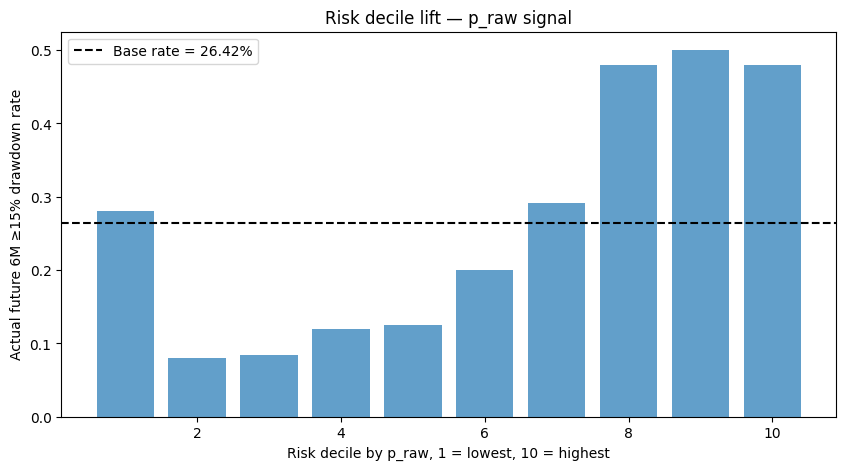

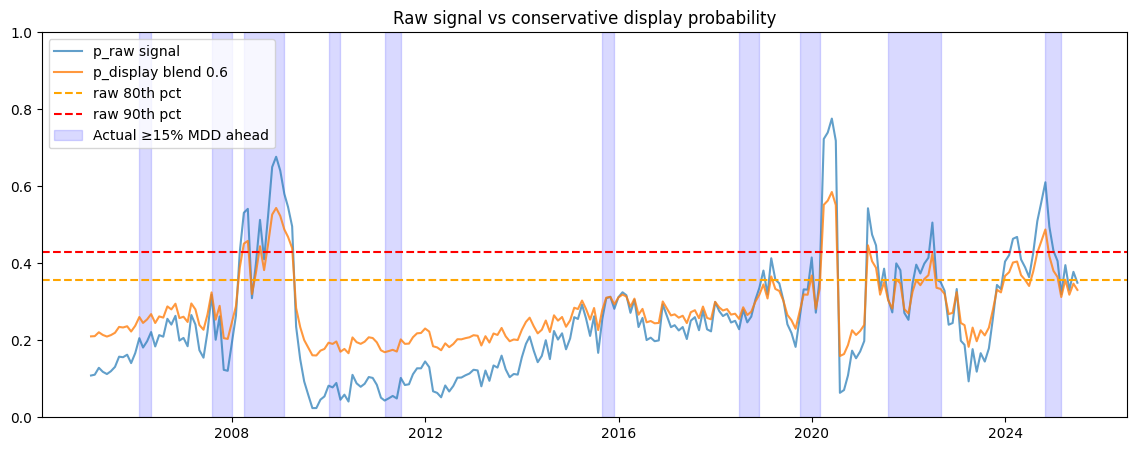

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import brier_score_loss, roc_auc_score, average_precision_score

# ===== 0. 准备数据 =====
risk = wf_debug.dropna().copy()
risk.index = pd.to_datetime(risk.index)

# 主信号：raw logistic
risk['p_signal'] = risk['p_raw']

# 对外展示概率：raw blend 0.6
risk['p_display'] = (
    risk['p_prior'] + 0.6 * (risk['p_raw'] - risk['p_prior'])
).clip(0.02, 0.80)

# ===== 1. 总体指标 =====
def metrics(y, p):
    out = {
        'n': len(y),
        'base_rate': y.mean(),
        'brier': brier_score_loss(y, p),
        'auc': roc_auc_score(y, p) if y.nunique() > 1 else np.nan,
        'pr_auc': average_precision_score(y, p) if y.nunique() > 1 else np.nan,
        'p_mean': p.mean(),
        'p_min': p.min(),
        'p_max': p.max(),
    }
    return out

summary = pd.DataFrame({
    'p_signal_raw': metrics(risk['label'], risk['p_signal']),
    'p_display_blend06': metrics(risk['label'], risk['p_display']),
}).T

print("=== Main metrics ===")
print(summary.round(4))


# ===== 2. Decile lift：按 p_signal 分成 10 桶 =====
risk['decile'] = pd.qcut(risk['p_signal'], 10, labels=False, duplicates='drop') + 1

decile_table = risk.groupby('decile').agg(
    n=('label', 'size'),
    avg_p_raw=('p_signal', 'mean'),
    avg_p_display=('p_display', 'mean'),
    actual_rate=('label', 'mean'),
    positives=('label', 'sum')
).reset_index()

decile_table['lift_vs_base'] = decile_table['actual_rate'] / risk['label'].mean()

print("\n=== Decile lift table ===")
print(decile_table.round(4))


# ===== 3. Top bucket hit rates =====
threshold_rows = []

for q in [0.50, 0.60, 0.70, 0.80, 0.90]:
    threshold = risk['p_signal'].quantile(q)
    sub = risk[risk['p_signal'] >= threshold]

    threshold_rows.append({
        'top_pct': f"top {int((1-q)*100)}%",
        'threshold_raw': threshold,
        'n': len(sub),
        'actual_rate': sub['label'].mean(),
        'base_rate': risk['label'].mean(),
        'lift': sub['label'].mean() / risk['label'].mean(),
        'avg_p_raw': sub['p_signal'].mean(),
        'avg_p_display': sub['p_display'].mean(),
        'positives': sub['label'].sum(),
    })

threshold_table = pd.DataFrame(threshold_rows)

print("\n=== Top bucket hit rates ===")
print(threshold_table.round(4))


# ===== 4. Low-risk bucket false negative check =====
low_rows = []

for q in [0.10, 0.20, 0.30]:
    threshold = risk['p_signal'].quantile(q)
    sub = risk[risk['p_signal'] <= threshold]

    low_rows.append({
        'bottom_pct': f"bottom {int(q*100)}%",
        'threshold_raw': threshold,
        'n': len(sub),
        'actual_rate': sub['label'].mean(),
        'base_rate': risk['label'].mean(),
        'lift_vs_base': sub['label'].mean() / risk['label'].mean(),
        'positives': sub['label'].sum(),
    })

low_table = pd.DataFrame(low_rows)

print("\n=== Low-risk bucket check ===")
print(low_table.round(4))


# ===== 5. 画 decile lift 图 =====
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(decile_table['decile'], decile_table['actual_rate'], alpha=0.7)
ax.axhline(risk['label'].mean(), linestyle='--', color='black', label=f"Base rate = {risk['label'].mean():.2%}")

ax.set_xlabel("Risk decile by p_raw, 1 = lowest, 10 = highest")
ax.set_ylabel("Actual future 6M ≥15% drawdown rate")
ax.set_title("Risk decile lift — p_raw signal")
ax.legend()

plt.show()


# ===== 6. 画时间序列：raw vs display =====
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(risk.index, risk['p_signal'], label='p_raw signal', alpha=0.7)
ax.plot(risk.index, risk['p_display'], label='p_display blend 0.6', alpha=0.8)

ax.axhline(risk['p_signal'].quantile(0.80), linestyle='--', color='orange', label='raw 80th pct')
ax.axhline(risk['p_signal'].quantile(0.90), linestyle='--', color='red', label='raw 90th pct')

ax.fill_between(
    risk.index,
    0,
    1,
    where=risk['label'] == 1,
    alpha=0.15,
    color='blue',
    label='Actual ≥15% MDD ahead'
)

ax.set_ylim(0, 1)
ax.set_title("Raw signal vs conservative display probability")
ax.legend(loc='upper left')

plt.show()

In [42]:
import pandas as pd
import numpy as np

# ===== 0. 准备数据 =====
risk = wf_debug.dropna().copy()
risk.index = pd.to_datetime(risk.index)

risk['p_signal'] = risk['p_raw']
risk['p_display'] = (
    risk['p_prior'] + 0.6 * (risk['p_raw'] - risk['p_prior'])
).clip(0.02, 0.80)

# 合并原始特征，方便看 false negatives 的特征状态
feature_cols = [c for c in df_v2.columns if c != 'label_15']
risk_features = risk.join(df_v2[feature_cols], how='left')

# ===== 1. bottom 10% false negatives =====
q10 = risk_features['p_signal'].quantile(0.10)
bottom10 = risk_features[risk_features['p_signal'] <= q10].copy()

bottom10_fn = bottom10[bottom10['label'] == 1].copy()

print("=== Bottom 10% false negatives ===")
print(f"bottom10 threshold = {q10:.4f}")
print(f"bottom10 n = {len(bottom10)}, positives = {bottom10['label'].sum()}, hit rate = {bottom10['label'].mean():.2%}")
print("\nFalse negative dates:")
print(bottom10_fn[['p_signal', 'p_display', 'label', 'train_base_rate', 'calib_base_rate'] + feature_cols].round(4))


# ===== 2. bottom 20% false negatives =====
q20 = risk_features['p_signal'].quantile(0.20)
bottom20 = risk_features[risk_features['p_signal'] <= q20].copy()
bottom20_fn = bottom20[bottom20['label'] == 1].copy()

print("\n=== Bottom 20% false negatives ===")
print(f"bottom20 threshold = {q20:.4f}")
print(f"bottom20 n = {len(bottom20)}, positives = {bottom20['label'].sum()}, hit rate = {bottom20['label'].mean():.2%}")
print("\nFalse negative dates:")
print(bottom20_fn[['p_signal', 'p_display', 'label'] + feature_cols].round(4))


# ===== 3. top 10% high-risk dates =====
q90 = risk_features['p_signal'].quantile(0.90)
top10 = risk_features[risk_features['p_signal'] >= q90].copy()

print("\n=== Top 10% high-risk dates ===")
print(f"top10 threshold = {q90:.4f}")
print(f"top10 n = {len(top10)}, positives = {top10['label'].sum()}, hit rate = {top10['label'].mean():.2%}")
print(top10[['p_signal', 'p_display', 'label'] + feature_cols].round(4))


# ===== 4. top 20% high-risk dates =====
q80 = risk_features['p_signal'].quantile(0.80)
top20 = risk_features[risk_features['p_signal'] >= q80].copy()

print("\n=== Top 20% high-risk dates summary by year ===")
top20_by_year = top20.groupby(top20.index.year).agg(
    n=('label', 'size'),
    positives=('label', 'sum'),
    hit_rate=('label', 'mean'),
    avg_p=('p_signal', 'mean')
)

print(top20_by_year.round(4))


# ===== 5. 按年份看所有正样本是否被模型捕捉 =====
all_pos = risk_features[risk_features['label'] == 1].copy()
all_pos['risk_decile'] = pd.qcut(risk_features['p_signal'], 10, labels=False, duplicates='drop') + 1

print("\n=== All positive labels by year and risk decile ===")
pos_by_year = all_pos.groupby(all_pos.index.year).agg(
    positives=('label', 'size'),
    avg_p=('p_signal', 'mean'),
    min_p=('p_signal', 'min'),
    max_p=('p_signal', 'max'),
    avg_decile=('risk_decile', 'mean')
)

print(pos_by_year.round(4))


# ===== 6. 保存方便后续查看 =====
bottom10_fn.to_csv('/content/bottom10_false_negatives.csv')
top10.to_csv('/content/top10_high_risk_dates.csv')
all_pos.to_csv('/content/all_positive_labels.csv')

print("\nSaved:")
print("/content/bottom10_false_negatives.csv")
print("/content/top10_high_risk_dates.csv")
print("/content/all_positive_labels.csv")

=== Bottom 10% false negatives ===
bottom10 threshold = 0.0832
bottom10 n = 25, positives = 7, hit rate = 28.00%

False negative dates:
            p_signal  p_display  label  train_base_rate  calib_base_rate  \
date                                                                       
2009-12-31    0.0820     0.1937      1           0.3645           0.3500   
2010-01-31    0.0776     0.1905      1           0.3627           0.3500   
2010-03-31    0.0456     0.1702      1           0.3592           0.3500   
2011-02-28    0.0434     0.1690      1           0.3410           0.4167   
2011-03-31    0.0492     0.1720      1           0.3394           0.4167   
2011-04-30    0.0554     0.1752      1           0.3379           0.4167   
2011-05-31    0.0489     0.1708      1           0.3364           0.4167   

            cape_z  dist_200dma  tsmom_12m  yc_10y3m  cfnai_ma3  bb_spread  \
date                                                                         
2009-12-31 -0.7617     

In [43]:
import numpy as np
import pandas as pd

# ===== 0. 准备数据 =====
risk = wf_debug.dropna().copy()
risk.index = pd.to_datetime(risk.index)

risk['p_signal'] = risk['p_raw']
risk['p_display'] = (
    risk['p_prior'] + 0.6 * (risk['p_raw'] - risk['p_prior'])
).clip(0.02, 0.80)

base_rate = risk['label'].mean()

print("=== Basic check ===")
print(f"N = {len(risk)}")
print(f"Start = {risk.index.min()}")
print(f"End = {risk.index.max()}")
print(f"Base rate = {base_rate:.2%}")
print(f"p_raw range = {risk['p_signal'].min():.4f} to {risk['p_signal'].max():.4f}")


# ===== 1. Decile lift =====
risk['decile'] = pd.qcut(risk['p_signal'], 10, labels=False, duplicates='drop') + 1

decile_table = risk.groupby('decile').agg(
    n=('label', 'size'),
    avg_p_raw=('p_signal', 'mean'),
    avg_p_display=('p_display', 'mean'),
    actual_rate=('label', 'mean'),
    positives=('label', 'sum')
).reset_index()

decile_table['lift_vs_base'] = decile_table['actual_rate'] / base_rate

print("\n=== Corrected decile lift table ===")
print(decile_table.round(4))


# ===== 2. Top bucket hit rates =====
threshold_rows = []

for q in [0.50, 0.60, 0.70, 0.80, 0.90]:
    threshold = risk['p_signal'].quantile(q)
    sub = risk[risk['p_signal'] >= threshold]

    threshold_rows.append({
        'top_pct': f"top {int((1-q)*100)}%",
        'threshold_raw': threshold,
        'n': len(sub),
        'actual_rate': sub['label'].mean(),
        'base_rate': base_rate,
        'lift': sub['label'].mean() / base_rate,
        'avg_p_raw': sub['p_signal'].mean(),
        'avg_p_display': sub['p_display'].mean(),
        'positives': sub['label'].sum(),
    })

threshold_table = pd.DataFrame(threshold_rows)

print("\n=== Corrected top bucket hit rates ===")
print(threshold_table.round(4))


# ===== 3. Low-risk bucket check =====
low_rows = []

for q in [0.10, 0.20, 0.30]:
    threshold = risk['p_signal'].quantile(q)
    sub = risk[risk['p_signal'] <= threshold]

    low_rows.append({
        'bottom_pct': f"bottom {int(q*100)}%",
        'threshold_raw': threshold,
        'n': len(sub),
        'actual_rate': sub['label'].mean(),
        'base_rate': base_rate,
        'lift_vs_base': sub['label'].mean() / base_rate,
        'positives': sub['label'].sum(),
    })

low_table = pd.DataFrame(low_rows)

print("\n=== Corrected low-risk bucket check ===")
print(low_table.round(4))


# ===== 4. 正样本 cluster lead-time 诊断 =====
risk['is_positive'] = risk['label'].astype(int)

# 给连续正样本分组
risk['pos_cluster_id'] = 0
cluster = 0
prev = 0

for idx in risk.index:
    cur = risk.loc[idx, 'is_positive']
    if cur == 1 and prev == 0:
        cluster += 1
    if cur == 1:
        risk.loc[idx, 'pos_cluster_id'] = cluster
    prev = cur

# 定义高风险阈值：raw 80th / 90th percentile
q80 = risk['p_signal'].quantile(0.80)
q90 = risk['p_signal'].quantile(0.90)

cluster_rows = []

for cid in sorted(risk['pos_cluster_id'].unique()):
    if cid == 0:
        continue

    pos_period = risk[risk['pos_cluster_id'] == cid]
    start_date = pos_period.index.min()
    end_date = pos_period.index.max()

    # 看正样本开始前 6 个月到结束期间
    window_start = start_date - pd.DateOffset(months=6)
    window_end = end_date
    window = risk[(risk.index >= window_start) & (risk.index <= window_end)]

    first_q80 = window[window['p_signal'] >= q80].index.min()
    first_q90 = window[window['p_signal'] >= q90].index.min()

    def months_diff(a, b):
        if pd.isna(a):
            return np.nan
        return (a.year - b.year) * 12 + (a.month - b.month)

    cluster_rows.append({
        'cluster_id': cid,
        'positive_start': start_date,
        'positive_end': end_date,
        'positive_months': len(pos_period),
        'avg_p_during_positive': pos_period['p_signal'].mean(),
        'max_p_pre_or_during': window['p_signal'].max(),
        'first_q80_date': first_q80,
        'first_q80_months_vs_start': months_diff(first_q80, start_date),
        'first_q90_date': first_q90,
        'first_q90_months_vs_start': months_diff(first_q90, start_date),
    })

cluster_table = pd.DataFrame(cluster_rows)

print("\n=== Positive cluster lead-time diagnostics ===")
print(cluster_table.round(4))


# ===== 5. 高风险年份 summary =====
top20 = risk[risk['p_signal'] >= q80].copy()

top20_by_year = top20.groupby(top20.index.year).agg(
    n=('label', 'size'),
    positives=('label', 'sum'),
    hit_rate=('label', 'mean'),
    avg_p=('p_signal', 'mean')
)

print("\n=== Top 20% high-risk dates summary by year ===")
print(top20_by_year.round(4))

=== Basic check ===
N = 246
Start = 2005-01-31 00:00:00
End = 2025-06-30 00:00:00
Base rate = 26.42%
p_raw range = 0.0239 to 0.7758

=== Corrected decile lift table ===
   decile   n  avg_p_raw  avg_p_display  actual_rate  positives  lift_vs_base
0       1  25     0.0586         0.1767       0.2800          7        1.0597
1       2  25     0.1010         0.2004       0.0800          2        0.3028
2       3  24     0.1326         0.2163       0.0833          2        0.3154
3       4  25     0.1749         0.2363       0.1200          3        0.4542
4       5  24     0.2093         0.2549       0.1250          3        0.4731
5       6  25     0.2444         0.2716       0.2000          5        0.7569
6       7  24     0.2745         0.2887       0.2917          7        1.1038
7       8  25     0.3283         0.3192       0.4800         12        1.8166
8       9  24     0.3963         0.3599       0.5000         12        1.8923
9      10  25     0.5665         0.4674       0.480

In [44]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import brier_score_loss, roc_auc_score, average_precision_score

# ============================================================
# Step 9: Actionable label test
# 目标：
# 旧 label = future peak-to-trough drawdown <= -15%
# 新 label = future min return from current price <= -15%
# ============================================================

# ===== 1. 重新生成两个 label =====

def future_stats_from_current(prices, current_idx, horizon_days=126):
    """
    返回两个未来6M风险指标：
    1) future_6m_min_ret_from_current:
       从当前价格出发，未来6M最低点收益
    2) future_6m_peak_to_trough_mdd:
       未来6M窗口内任意未来高点到未来低点的最大回撤
    """
    if current_idx + horizon_days >= len(prices):
        return np.nan, np.nan

    future_prices = prices.iloc[current_idx : current_idx + horizon_days + 1]
    current_price = future_prices.iloc[0]

    # 新 label 需要的指标：从今天价格算起，未来最低点收益
    min_ret_from_current = future_prices.min() / current_price - 1

    # 旧 label 指标：未来窗口内部 peak-to-trough 最大回撤
    running_max = future_prices.cummax()
    peak_to_trough_mdd = (future_prices / running_max - 1).min()

    return min_ret_from_current, peak_to_trough_mdd


month_ends = ndx_d.resample('ME').last().index

rows = []
for d in month_ends:
    if (ndx_d.index <= d).any():
        d_actual = ndx_d.index[ndx_d.index <= d][-1]
    else:
        rows.append((d, np.nan, np.nan))
        continue

    idx = ndx_d.index.get_loc(d_actual)
    min_ret_current, p2t_mdd = future_stats_from_current(ndx_d['ndx_close'], idx)

    rows.append((d, min_ret_current, p2t_mdd))


labels_action = pd.DataFrame(
    rows,
    columns=[
        'date',
        'future_6m_min_ret_from_current',
        'future_6m_peak_to_trough_mdd'
    ]
).set_index('date')

labels_action['label_current_15'] = np.where(
    labels_action['future_6m_min_ret_from_current'].isna(),
    np.nan,
    (labels_action['future_6m_min_ret_from_current'] <= -0.15).astype(int)
)

labels_action['label_p2t_15'] = np.where(
    labels_action['future_6m_peak_to_trough_mdd'].isna(),
    np.nan,
    (labels_action['future_6m_peak_to_trough_mdd'] <= -0.15).astype(int)
)

print("=== Label comparison ===")
print(labels_action.tail(12))

valid_label_compare = labels_action.dropna()

print("\nBase rates:")
print("Peak-to-trough label base rate:", valid_label_compare['label_p2t_15'].mean())
print("Current-price label base rate:", valid_label_compare['label_current_15'].mean())

print("\nCrosstab: old p2t label vs new current-price label")
print(pd.crosstab(
    valid_label_compare['label_p2t_15'],
    valid_label_compare['label_current_15'],
    rownames=['old_p2t'],
    colnames=['new_current']
))

# 看旧label=1但新label=0的日期：这些就是“未来有局部回撤，但从当前买入不一定亏15%”
old_pos_new_neg = valid_label_compare[
    (valid_label_compare['label_p2t_15'] == 1) &
    (valid_label_compare['label_current_15'] == 0)
]

print("\nOld positive but new negative count:", len(old_pos_new_neg))
print(old_pos_new_neg.tail(30))


# ===== 2. 构造新 df：只保留 6 个真实特征 + 新 label，避免任何泄漏 =====

feature_cols_model = [
    'cape_z',
    'dist_200dma',
    'tsmom_12m',
    'yc_10y3m',
    'cfnai_ma3',
    'bb_spread'
]

df_action = features_v2[feature_cols_model].join(
    labels_action[['future_6m_min_ret_from_current', 'label_current_15']],
    how='inner'
)

df_action_model = df_action.dropna(subset=feature_cols_model + ['label_current_15']).copy()
df_action_model['label_15'] = df_action_model['label_current_15'].astype(int)

# 模型输入只保留特征和 label，future return 不进入模型
df_action_model_for_fit = df_action_model[feature_cols_model + ['label_15']].copy()

print("\n=== New actionable df ===")
print(f"Rows: {len(df_action_model_for_fit)}")
print(f"Start: {df_action_model_for_fit.index.min()}")
print(f"End: {df_action_model_for_fit.index.max()}")
print(f"Label distribution: {df_action_model_for_fit['label_15'].value_counts().to_dict()}")
print(f"Base rate: {df_action_model_for_fit['label_15'].mean():.2%}")


# ===== 3. Walk-forward raw logistic：无 isotonic，只保留 p_raw =====

def walk_forward_raw_only(
    df,
    feature_cols,
    embargo_months=6,
    train_min_samples=60,
    train_min_positives=5,
    oos_start='2005-01-01',
    winsorize_quantiles=(0.01, 0.99),
    calibration_window_months=60,
):
    """
    为了和之前 p_raw 可比：
    - 仍然预留最后60个月不训练，相当于保守训练
    - 不做 isotonic
    - 输出 p_raw、p_prior、p_display
    """
    results = []
    all_dates = sorted(df.index.tolist())
    oos_start_ts = pd.Timestamp(oos_start)

    for cutoff in all_dates:
        if cutoff < oos_start_ts:
            continue

        cutoff_train_end = cutoff - pd.DateOffset(months=embargo_months)
        train_full = df[df.index < cutoff_train_end].copy()
        test_part = df[df.index == cutoff].copy()

        if len(train_full) < train_min_samples + calibration_window_months:
            continue
        if train_full['label_15'].sum() < train_min_positives:
            continue
        if len(test_part) == 0:
            continue

        # winsorize bounds 只用 cutoff 之前数据
        lo_q, hi_q = winsorize_quantiles
        bounds = {
            col: (
                train_full[col].quantile(lo_q),
                train_full[col].quantile(hi_q)
            )
            for col in feature_cols
        }

        train_w = train_full.copy()
        test_w = test_part.copy()

        for col in feature_cols:
            lo, hi = bounds[col]
            train_w[col] = train_w[col].clip(lo, hi)
            test_w[col] = test_w[col].clip(lo, hi)

        # 为了和之前 p_raw 设置一致，仍然把最后60个月拿出来不用
        train_for_fit = train_w.iloc[:-calibration_window_months].copy()

        if train_for_fit['label_15'].sum() < train_min_positives:
            continue

        X_tr = train_for_fit[feature_cols]
        y_tr = train_for_fit['label_15']

        scaler = StandardScaler().fit(X_tr)

        model = LogisticRegression(
            C=1.0,
            max_iter=1000,
            random_state=42
        ).fit(
            scaler.transform(X_tr),
            y_tr
        )

        p_raw = model.predict_proba(
            scaler.transform(test_w[feature_cols])
        )[:, 1][0]

        # prior 只用 cutoff - embargo 之前可见历史
        p_prior = train_full['label_15'].mean()

        p_display = np.clip(
            p_prior + 0.6 * (p_raw - p_prior),
            0.02,
            0.80
        )

        results.append({
            'date': cutoff,
            'p_raw': float(p_raw),
            'p_prior': float(p_prior),
            'p_display': float(p_display),
            'label': int(test_part['label_15'].iloc[0]),
        })

    return pd.DataFrame(results).set_index('date')


wf_action = walk_forward_raw_only(
    df_action_model_for_fit,
    feature_cols=feature_cols_model,
    oos_start='2005-01-01'
)


# ===== 4. 评估函数 =====

def safe_metrics(y, p):
    y = pd.Series(y).astype(int)
    p = pd.Series(p).astype(float)

    out = {
        'n': len(y),
        'base_rate': y.mean(),
        'brier': brier_score_loss(y, p),
        'baseline_brier_const': brier_score_loss(y, [y.mean()] * len(y)),
        'auc': np.nan,
        'pr_auc': np.nan,
        'p_mean': p.mean(),
        'p_std': p.std(),
        'p_min': p.min(),
        'p_max': p.max(),
    }

    if y.nunique() > 1:
        out['auc'] = roc_auc_score(y, p)
        out['pr_auc'] = average_precision_score(y, p)

    return out


rows = []
for col in ['p_raw', 'p_display', 'p_prior']:
    m = safe_metrics(wf_action['label'], wf_action[col])
    m['model'] = col
    rows.append(m)

summary_action = pd.DataFrame(rows).set_index('model')

print("\n=== Actionable label: main metrics ===")
print(summary_action.round(4))


# ===== 5. Decile / top / low buckets =====

risk = wf_action.dropna().copy()
risk['p_signal'] = risk['p_raw']
risk['decile'] = pd.qcut(risk['p_signal'], 10, labels=False, duplicates='drop') + 1

base_rate = risk['label'].mean()

decile_table = risk.groupby('decile').agg(
    n=('label', 'size'),
    avg_p_raw=('p_signal', 'mean'),
    avg_p_display=('p_display', 'mean'),
    actual_rate=('label', 'mean'),
    positives=('label', 'sum')
).reset_index()

decile_table['lift_vs_base'] = decile_table['actual_rate'] / base_rate

print("\n=== Actionable label: decile lift table ===")
print(decile_table.round(4))


threshold_rows = []
for q in [0.50, 0.60, 0.70, 0.80, 0.90]:
    threshold = risk['p_signal'].quantile(q)
    sub = risk[risk['p_signal'] >= threshold]

    threshold_rows.append({
        'top_pct': f"top {int((1-q)*100)}%",
        'threshold_raw': threshold,
        'n': len(sub),
        'actual_rate': sub['label'].mean(),
        'base_rate': base_rate,
        'lift': sub['label'].mean() / base_rate,
        'avg_p_raw': sub['p_signal'].mean(),
        'avg_p_display': sub['p_display'].mean(),
        'positives': sub['label'].sum(),
    })

threshold_table = pd.DataFrame(threshold_rows)

print("\n=== Actionable label: top bucket hit rates ===")
print(threshold_table.round(4))


low_rows = []
for q in [0.10, 0.20, 0.30]:
    threshold = risk['p_signal'].quantile(q)
    sub = risk[risk['p_signal'] <= threshold]

    low_rows.append({
        'bottom_pct': f"bottom {int(q*100)}%",
        'threshold_raw': threshold,
        'n': len(sub),
        'actual_rate': sub['label'].mean(),
        'base_rate': base_rate,
        'lift_vs_base': sub['label'].mean() / base_rate,
        'positives': sub['label'].sum(),
    })

low_table = pd.DataFrame(low_rows)

print("\n=== Actionable label: low-risk bucket check ===")
print(low_table.round(4))

=== Label comparison ===
            future_6m_min_ret_from_current  future_6m_peak_to_trough_mdd  \
date                                                                       
2025-01-31                       -0.204285                     -0.229315   
2025-02-28                       -0.181667                     -0.181667   
2025-03-31                       -0.113497                     -0.127229   
2025-04-30                        0.000000                     -0.036396   
2025-05-31                        0.000000                     -0.079077   
2025-06-30                       -0.008857                     -0.079077   
2025-07-31                             NaN                           NaN   
2025-08-31                             NaN                           NaN   
2025-09-30                             NaN                           NaN   
2025-10-31                             NaN                           NaN   
2025-11-30                             NaN                     

In [45]:
import pandas as pd
import numpy as np

# ============================================================
# Step 10: Diagnose actionable label non-monotonic deciles
# ============================================================

# 重新准备 M2 risk table
risk_m2 = wf_action.dropna().copy()
risk_m2.index = pd.to_datetime(risk_m2.index)

risk_m2['p_signal'] = risk_m2['p_raw']
risk_m2['p_display'] = risk_m2['p_display']

# 合并 6个特征 + 新label的未来收益，方便诊断
diagnostic_cols = feature_cols_model + ['future_6m_min_ret_from_current', 'label_current_15']

risk_m2_diag = risk_m2.join(
    df_action[diagnostic_cols],
    how='left'
)

# decile
risk_m2_diag['decile'] = pd.qcut(
    risk_m2_diag['p_signal'],
    10,
    labels=False,
    duplicates='drop'
) + 1

# ===== 1. Top decile false positives =====
top_decile = risk_m2_diag[risk_m2_diag['decile'] == risk_m2_diag['decile'].max()].copy()
top_decile_fp = top_decile[top_decile['label'] == 0].copy()

print("=== M2 top decile summary ===")
print(f"Top decile n = {len(top_decile)}")
print(f"Top decile positives = {top_decile['label'].sum()}")
print(f"Top decile hit rate = {top_decile['label'].mean():.2%}")

print("\n=== M2 top decile false positives ===")
print(top_decile_fp[
    ['p_signal', 'p_display', 'label', 'future_6m_min_ret_from_current'] + feature_cols_model
].round(4))


# ===== 2. Decile 7 positives =====
decile7_pos = risk_m2_diag[
    (risk_m2_diag['decile'] == 7) &
    (risk_m2_diag['label'] == 1)
].copy()

print("\n=== M2 decile 7 positives ===")
print(f"Decile 7 positive count = {len(decile7_pos)}")
print(decile7_pos[
    ['p_signal', 'p_display', 'label', 'future_6m_min_ret_from_current'] + feature_cols_model
].round(4))


# ===== 3. Bottom 30%唯一漏报 =====
q30 = risk_m2_diag['p_signal'].quantile(0.30)
bottom30 = risk_m2_diag[risk_m2_diag['p_signal'] <= q30].copy()
bottom30_fn = bottom30[bottom30['label'] == 1].copy()

print("\n=== M2 bottom 30% false negatives ===")
print(f"bottom30 threshold = {q30:.4f}")
print(f"bottom30 n = {len(bottom30)}")
print(f"bottom30 positives = {bottom30['label'].sum()}")
print(bottom30_fn[
    ['p_signal', 'p_display', 'label', 'future_6m_min_ret_from_current'] + feature_cols_model
].round(4))


# ===== 4. 按 decile 输出每个特征均值，看看 top decile 为什么特殊 =====
feature_profile = risk_m2_diag.groupby('decile').agg(
    n=('label', 'size'),
    hit_rate=('label', 'mean'),
    avg_p=('p_signal', 'mean'),
    avg_future_min_ret=('future_6m_min_ret_from_current', 'mean'),
    cape_z=('cape_z', 'mean'),
    dist_200dma=('dist_200dma', 'mean'),
    tsmom_12m=('tsmom_12m', 'mean'),
    yc_10y3m=('yc_10y3m', 'mean'),
    cfnai_ma3=('cfnai_ma3', 'mean'),
    bb_spread=('bb_spread', 'mean')
)

print("\n=== M2 feature profile by decile ===")
print(feature_profile.round(4))

=== M2 top decile summary ===
Top decile n = 25
Top decile positives = 3
Top decile hit rate = 12.00%

=== M2 top decile false positives ===
            p_signal  p_display  label  future_6m_min_ret_from_current  \
date                                                                     
2006-08-31    0.4549     0.3537      0                         -0.0094   
2006-09-30    0.4232     0.3343      0                         -0.0129   
2006-10-31    0.4631     0.3578      0                         -0.0165   
2007-02-28    0.4502     0.3487      0                         -0.0276   
2007-03-31    0.3883     0.3112      0                          0.0000   
2007-07-31    0.3753     0.3021      0                         -0.0740   
2008-02-29    0.4186     0.3259      0                         -0.0414   
2008-03-31    0.4785     0.3615      0                         -0.0839   
2008-11-30    0.4644     0.3586      0                         -0.1197   
2008-12-31    0.4665     0.3611      0       

In [46]:
import numpy as np
import pandas as pd

# ============================================================
# Step 11: Add price-stage features for M2 actionable label
# ============================================================

# ===== 1. 从 NDX 日频价格生成月度 price-stage features =====

px = ndx_d[['ndx_close']].copy()
px['ret_d'] = px['ndx_close'].pct_change()

# 月末价格
px_m = px[['ndx_close']].resample('ME').last()

# 月度收益特征
px_m['ret_1m'] = px_m['ndx_close'].pct_change(1)
px_m['ret_3m'] = px_m['ndx_close'].pct_change(3)
px_m['ret_6m'] = px_m['ndx_close'].pct_change(6)

# 当前价格距离过去 6M / 12M 高点
# 注意：这里只用截至当前月末之前/当日的历史价格，不用未来数据
px_m['rolling_6m_high'] = px_m['ndx_close'].rolling(6, min_periods=3).max()
px_m['rolling_12m_high'] = px_m['ndx_close'].rolling(12, min_periods=6).max()

px_m['dd_from_6m_high'] = px_m['ndx_close'] / px_m['rolling_6m_high'] - 1
px_m['dd_from_12m_high'] = px_m['ndx_close'] / px_m['rolling_12m_high'] - 1

# 日频波动率，月末取值
px['vol_3m_daily'] = px['ret_d'].rolling(63).std() * np.sqrt(252)
px['vol_12m_daily'] = px['ret_d'].rolling(252).std() * np.sqrt(252)

vol_m = px[['vol_3m_daily', 'vol_12m_daily']].resample('ME').last()
vol_m.columns = ['vol_3m', 'vol_12m']
vol_m['vol_ratio_3m_12m'] = vol_m['vol_3m'] / vol_m['vol_12m']

price_stage = px_m[
    [
        'ret_1m',
        'ret_3m',
        'ret_6m',
        'dd_from_6m_high',
        'dd_from_12m_high',
    ]
].join(
    vol_m[['vol_3m', 'vol_ratio_3m_12m']],
    how='left'
)

print("=== Price-stage features check ===")
print(price_stage.tail(12))
print(price_stage.describe().round(4))


# ===== 2. 构建 M2 enhanced feature set =====

base_features = [
    'cape_z',
    'dist_200dma',
    'tsmom_12m',
    'yc_10y3m',
    'cfnai_ma3',
    'bb_spread'
]

price_features = [
    'ret_1m',
    'ret_3m',
    'ret_6m',
    'dd_from_6m_high',
    'dd_from_12m_high',
    'vol_3m',
    'vol_ratio_3m_12m'
]

feature_cols_m2_enhanced = base_features + price_features

features_m2_enhanced = features_v2[base_features].join(price_stage[price_features], how='left')

df_action_enhanced = features_m2_enhanced.join(
    labels_action[['future_6m_min_ret_from_current', 'label_current_15']],
    how='inner'
)

df_action_enhanced_model = df_action_enhanced.dropna(
    subset=feature_cols_m2_enhanced + ['label_current_15']
).copy()

df_action_enhanced_model['label_15'] = df_action_enhanced_model['label_current_15'].astype(int)

df_action_enhanced_for_fit = df_action_enhanced_model[
    feature_cols_m2_enhanced + ['label_15']
].copy()

print("\n=== M2 enhanced df ===")
print(f"Rows: {len(df_action_enhanced_for_fit)}")
print(f"Start: {df_action_enhanced_for_fit.index.min()}")
print(f"End: {df_action_enhanced_for_fit.index.max()}")
print(f"Label distribution: {df_action_enhanced_for_fit['label_15'].value_counts().to_dict()}")
print(f"Base rate: {df_action_enhanced_for_fit['label_15'].mean():.2%}")
print("Features:")
print(feature_cols_m2_enhanced)


# ===== 3. 复用之前的 walk_forward_raw_only =====
# 如果你的 notebook 里已经有 walk_forward_raw_only，这里可以直接调用

wf_action_enhanced = walk_forward_raw_only(
    df_action_enhanced_for_fit,
    feature_cols=feature_cols_m2_enhanced,
    oos_start='2005-01-01'
)


# ===== 4. 主指标对比：原 M2 vs enhanced M2 =====

from sklearn.metrics import brier_score_loss, roc_auc_score, average_precision_score

def safe_metrics(y, p):
    y = pd.Series(y).astype(int)
    p = pd.Series(p).astype(float)

    out = {
        'n': len(y),
        'base_rate': y.mean(),
        'brier': brier_score_loss(y, p),
        'baseline_brier_const': brier_score_loss(y, [y.mean()] * len(y)),
        'auc': np.nan,
        'pr_auc': np.nan,
        'p_mean': p.mean(),
        'p_std': p.std(),
        'p_min': p.min(),
        'p_max': p.max(),
    }

    if y.nunique() > 1:
        out['auc'] = roc_auc_score(y, p)
        out['pr_auc'] = average_precision_score(y, p)

    return out


rows = []

# 原 M2
for col in ['p_raw', 'p_display', 'p_prior']:
    m = safe_metrics(wf_action['label'], wf_action[col])
    m['model'] = f'old_M2_{col}'
    rows.append(m)

# Enhanced M2
for col in ['p_raw', 'p_display', 'p_prior']:
    m = safe_metrics(wf_action_enhanced['label'], wf_action_enhanced[col])
    m['model'] = f'enhanced_M2_{col}'
    rows.append(m)

compare_summary = pd.DataFrame(rows).set_index('model')

print("\n=== Old M2 vs Enhanced M2: main metrics ===")
print(compare_summary.round(4))


# ===== 5. Enhanced M2 decile / top / low 检查 =====

risk_enh = wf_action_enhanced.dropna().copy()
risk_enh['p_signal'] = risk_enh['p_raw']
risk_enh['decile'] = pd.qcut(risk_enh['p_signal'], 10, labels=False, duplicates='drop') + 1

base_rate_enh = risk_enh['label'].mean()

decile_enh = risk_enh.groupby('decile').agg(
    n=('label', 'size'),
    avg_p_raw=('p_signal', 'mean'),
    avg_p_display=('p_display', 'mean'),
    actual_rate=('label', 'mean'),
    positives=('label', 'sum')
).reset_index()

decile_enh['lift_vs_base'] = decile_enh['actual_rate'] / base_rate_enh

print("\n=== Enhanced M2: decile lift table ===")
print(decile_enh.round(4))


threshold_rows = []

for q in [0.50, 0.60, 0.70, 0.80, 0.90]:
    threshold = risk_enh['p_signal'].quantile(q)
    sub = risk_enh[risk_enh['p_signal'] >= threshold]

    threshold_rows.append({
        'top_pct': f"top {int((1-q)*100)}%",
        'threshold_raw': threshold,
        'n': len(sub),
        'actual_rate': sub['label'].mean(),
        'base_rate': base_rate_enh,
        'lift': sub['label'].mean() / base_rate_enh,
        'avg_p_raw': sub['p_signal'].mean(),
        'avg_p_display': sub['p_display'].mean(),
        'positives': sub['label'].sum(),
    })

top_enh = pd.DataFrame(threshold_rows)

print("\n=== Enhanced M2: top bucket hit rates ===")
print(top_enh.round(4))


low_rows = []

for q in [0.10, 0.20, 0.30]:
    threshold = risk_enh['p_signal'].quantile(q)
    sub = risk_enh[risk_enh['p_signal'] <= threshold]

    low_rows.append({
        'bottom_pct': f"bottom {int(q*100)}%",
        'threshold_raw': threshold,
        'n': len(sub),
        'actual_rate': sub['label'].mean(),
        'base_rate': base_rate_enh,
        'lift_vs_base': sub['label'].mean() / base_rate_enh,
        'positives': sub['label'].sum(),
    })

low_enh = pd.DataFrame(low_rows)

print("\n=== Enhanced M2: low-risk bucket check ===")
print(low_enh.round(4))


# ===== 6. Enhanced M2 feature profile by decile =====

risk_enh_diag = risk_enh.join(
    df_action_enhanced[feature_cols_m2_enhanced + ['future_6m_min_ret_from_current']],
    how='left'
)

feature_profile_enh = risk_enh_diag.groupby('decile').agg(
    n=('label', 'size'),
    hit_rate=('label', 'mean'),
    avg_p=('p_signal', 'mean'),
    avg_future_min_ret=('future_6m_min_ret_from_current', 'mean'),
    cape_z=('cape_z', 'mean'),
    dist_200dma=('dist_200dma', 'mean'),
    tsmom_12m=('tsmom_12m', 'mean'),
    ret_1m=('ret_1m', 'mean'),
    ret_3m=('ret_3m', 'mean'),
    ret_6m=('ret_6m', 'mean'),
    dd_from_6m_high=('dd_from_6m_high', 'mean'),
    dd_from_12m_high=('dd_from_12m_high', 'mean'),
    vol_3m=('vol_3m', 'mean'),
    vol_ratio_3m_12m=('vol_ratio_3m_12m', 'mean'),
    yc_10y3m=('yc_10y3m', 'mean'),
    cfnai_ma3=('cfnai_ma3', 'mean'),
    bb_spread=('bb_spread', 'mean')
)

print("\n=== Enhanced M2: feature profile by decile ===")
print(feature_profile_enh.round(4))

=== Price-stage features check ===
              ret_1m    ret_3m    ret_6m  dd_from_6m_high  dd_from_12m_high  \
Date                                                                          
2025-01-31  0.022172  0.079819  0.109264         0.000000          0.000000   
2025-02-28 -0.027639 -0.002196  0.066912        -0.027639         -0.027639   
2025-03-31 -0.076898 -0.082510 -0.038994        -0.102412         -0.102412   
2025-04-30  0.015176 -0.088790 -0.016058        -0.088790         -0.088790   
2025-05-31  0.090438  0.021862  0.019618        -0.006381         -0.006381   
2025-06-30  0.062697  0.176392  0.079327         0.000000          0.000000   
2025-07-31  0.023771  0.186352  0.081016         0.000000          0.000000   
2025-08-31  0.008498  0.097204  0.121191         0.000000          0.000000   
2025-09-30  0.054006  0.088231  0.280185         0.000000          0.000000   
2025-10-31  0.047737  0.113705  0.321246         0.000000          0.000000   
2025-11-30 -0.016

In [47]:
import numpy as np
import pandas as pd

# ============================================================
# Step 12: Combine M1 + M2 with post-crash overlay
# ============================================================

# ===== 0. 准备对齐数据 =====

combo = pd.DataFrame(index=wf_action.index)

# M1: market instability / peak-to-trough risk
combo['m1_p_raw'] = wf_debug['p_raw']

# M2: actionable current-price loss risk
combo['m2_p_raw'] = wf_action['p_raw']
combo['m2_p_display'] = wf_action['p_display']
combo['label_current_15'] = wf_action['label']

# 加入 price-stage，仅作为 overlay 规则，不重新训练
combo = combo.join(
    price_stage[
        [
            'ret_1m',
            'ret_3m',
            'ret_6m',
            'dd_from_6m_high',
            'dd_from_12m_high',
            'vol_3m',
            'vol_ratio_3m_12m',
        ]
    ],
    how='left'
)

# 加入原始特征，方便诊断
combo = combo.join(
    features_v2[
        [
            'cape_z',
            'dist_200dma',
            'tsmom_12m',
            'yc_10y3m',
            'cfnai_ma3',
            'bb_spread',
        ]
    ],
    how='left'
)

combo = combo.dropna().copy()

base_rate = combo['label_current_15'].mean()

print("=== Combo data check ===")
print(f"N = {len(combo)}")
print(f"Start = {combo.index.min()}")
print(f"End = {combo.index.max()}")
print(f"Base rate = {base_rate:.2%}")


# ===== 1. 定义 post-crash / already-de-risked flags =====
# 这些不是未来信息，都是当月月末可见状态

combo['post_crash_dd12_10'] = combo['dd_from_12m_high'] <= -0.10
combo['post_crash_dd12_15'] = combo['dd_from_12m_high'] <= -0.15
combo['post_crash_deep_stress'] = (
    (combo['dd_from_12m_high'] <= -0.10) &
    (combo['vol_3m'] >= 0.25)
)
combo['macro_shock_state'] = (
    (combo['cfnai_ma3'] <= -1.0) |
    (combo['vol_3m'] >= 0.35)
)

post_filters = {
    'none': pd.Series(False, index=combo.index),
    'exclude_dd12_le_10': combo['post_crash_dd12_10'],
    'exclude_dd12_le_15': combo['post_crash_dd12_15'],
    'exclude_deep_stress': combo['post_crash_deep_stress'],
    'exclude_macro_shock': combo['macro_shock_state'],
}


# ===== 2. Grid search 简单组合规则 =====
# 逻辑：
# SAFE = M2 很低
# RED = M1 高 + M2 不低 + 不是 post-crash
#
# 解释：
# M1 高说明未来市场可能不稳定；
# M2 不低说明从当前价格仍有亏损空间；
# post-crash 排除已经跌过/宏观已经爆雷后的状态。

rows = []

for m1_q in [0.60, 0.70, 0.80, 0.90]:
    m1_th = combo['m1_p_raw'].quantile(m1_q)

    for m2_safe_q in [0.20, 0.30, 0.40]:
        m2_safe_th = combo['m2_p_raw'].quantile(m2_safe_q)

        for m2_min_q in [0.30, 0.40, 0.50]:
            m2_min_th = combo['m2_p_raw'].quantile(m2_min_q)

            for filter_name, post_flag in post_filters.items():

                safe = combo['m2_p_raw'] <= m2_safe_th

                red = (
                    (combo['m1_p_raw'] >= m1_th) &
                    (combo['m2_p_raw'] >= m2_min_th) &
                    (~post_flag)
                )

                neutral = ~(safe | red)

                # 避免太小的红区样本没有意义
                if red.sum() < 10:
                    continue

                rows.append({
                    'm1_q': m1_q,
                    'm1_th': m1_th,
                    'm2_safe_q': m2_safe_q,
                    'm2_safe_th': m2_safe_th,
                    'm2_min_q': m2_min_q,
                    'm2_min_th': m2_min_th,
                    'post_filter': filter_name,

                    'safe_n': int(safe.sum()),
                    'safe_hit_rate': combo.loc[safe, 'label_current_15'].mean(),
                    'safe_lift': combo.loc[safe, 'label_current_15'].mean() / base_rate,

                    'red_n': int(red.sum()),
                    'red_hit_rate': combo.loc[red, 'label_current_15'].mean(),
                    'red_lift': combo.loc[red, 'label_current_15'].mean() / base_rate,

                    'neutral_n': int(neutral.sum()),
                    'neutral_hit_rate': combo.loc[neutral, 'label_current_15'].mean(),
                })

rules = pd.DataFrame(rows)

print("\n=== Best rules sorted by red_hit_rate, with reasonable coverage ===")
best_rules = rules[
    (rules['red_n'] >= 15) &
    (rules['safe_n'] >= 40)
].sort_values(
    ['red_hit_rate', 'red_n'],
    ascending=[False, False]
)

print(best_rules.head(20).round(4))


# ===== 3. 也看比较平衡的规则：red_lift 高，safe_hit_rate 低 =====

balanced_rules = rules[
    (rules['red_n'] >= 20) &
    (rules['safe_n'] >= 50) &
    (rules['safe_hit_rate'] <= base_rate * 0.5)
].copy()

balanced_rules['score'] = (
    balanced_rules['red_lift'] -
    balanced_rules['safe_lift']
)

print("\n=== Balanced rules: high red lift + low safe risk ===")
print(
    balanced_rules.sort_values(
        ['score', 'red_hit_rate'],
        ascending=[False, False]
    ).head(20).round(4)
)


# ===== 4. 选一个默认规则做详细输出 =====
# 优先选择 balanced 第一名；如果没有，就选 best_rules 第一名

if len(balanced_rules) > 0:
    chosen = balanced_rules.sort_values(
        ['score', 'red_hit_rate'],
        ascending=[False, False]
    ).iloc[0]
else:
    chosen = best_rules.iloc[0]

print("\n=== Chosen rule ===")
print(chosen.round(4))


# ===== 5. 用 chosen rule 生成状态分类 =====

m1_th = chosen['m1_th']
m2_safe_th = chosen['m2_safe_th']
m2_min_th = chosen['m2_min_th']
post_filter = chosen['post_filter']

post_flag = post_filters[post_filter]

combo['state'] = 'NEUTRAL'

combo.loc[
    combo['m2_p_raw'] <= m2_safe_th,
    'state'
] = 'GREEN_SAFE'

combo.loc[
    (combo['m1_p_raw'] >= m1_th) &
    (combo['m2_p_raw'] >= m2_min_th) &
    (~post_flag),
    'state'
] = 'RED_RISK'

# 如果同时满足，RED 优先
combo.loc[
    (combo['m1_p_raw'] >= m1_th) &
    (combo['m2_p_raw'] >= m2_min_th) &
    (~post_flag),
    'state'
] = 'RED_RISK'


state_table = combo.groupby('state').agg(
    n=('label_current_15', 'size'),
    hit_rate=('label_current_15', 'mean'),
    positives=('label_current_15', 'sum'),
    avg_m1_p=('m1_p_raw', 'mean'),
    avg_m2_p=('m2_p_raw', 'mean'),
    avg_dd12=('dd_from_12m_high', 'mean'),
    avg_vol3m=('vol_3m', 'mean'),
    avg_cfnai=('cfnai_ma3', 'mean')
).reset_index()

state_table['lift_vs_base'] = state_table['hit_rate'] / base_rate

print("\n=== State table for chosen rule ===")
print(state_table.round(4))


# ===== 6. RED / GREEN 日期检查 =====

print("\n=== RED_RISK dates ===")
print(
    combo[combo['state'] == 'RED_RISK'][
        [
            'm1_p_raw',
            'm2_p_raw',
            'label_current_15',
            'dd_from_12m_high',
            'vol_3m',
            'cfnai_ma3',
            'cape_z',
            'tsmom_12m',
        ]
    ].round(4)
)

print("\n=== GREEN_SAFE dates with positives, if any ===")
print(
    combo[
        (combo['state'] == 'GREEN_SAFE') &
        (combo['label_current_15'] == 1)
    ][
        [
            'm1_p_raw',
            'm2_p_raw',
            'label_current_15',
            'dd_from_12m_high',
            'vol_3m',
            'cfnai_ma3',
            'cape_z',
            'tsmom_12m',
        ]
    ].round(4)
)

=== Combo data check ===
N = 246
Start = 2005-01-31 00:00:00
End = 2025-06-30 00:00:00
Base rate = 15.45%

=== Best rules sorted by red_hit_rate, with reasonable coverage ===
     m1_q   m1_th  m2_safe_q  m2_safe_th  m2_min_q  m2_min_th  \
94    0.8  0.3577        0.2      0.0756       0.3     0.1009   
99    0.8  0.3577        0.2      0.0756       0.4     0.1253   
104   0.8  0.3577        0.2      0.0756       0.5     0.1385   
109   0.8  0.3577        0.3      0.1009       0.3     0.1009   
114   0.8  0.3577        0.3      0.1009       0.4     0.1253   
119   0.8  0.3577        0.3      0.1009       0.5     0.1385   
124   0.8  0.3577        0.4      0.1253       0.3     0.1009   
129   0.8  0.3577        0.4      0.1253       0.4     0.1253   
134   0.8  0.3577        0.4      0.1253       0.5     0.1385   
90    0.8  0.3577        0.2      0.0756       0.3     0.1009   
95    0.8  0.3577        0.2      0.0756       0.4     0.1253   
100   0.8  0.3577        0.2      0.0756     

In [48]:
import numpy as np
import pandas as pd

# ============================================================
# Step 13: Online threshold validation for M1 + M2 state rule
# ============================================================

# ===== 0. 准备数据 =====

online = pd.DataFrame(index=wf_action.index)

online['m1_p_raw'] = wf_debug['p_raw']
online['m2_p_raw'] = wf_action['p_raw']
online['label_current_15'] = wf_action['label']

online = online.join(
    price_stage[
        [
            'ret_1m',
            'ret_3m',
            'ret_6m',
            'dd_from_6m_high',
            'dd_from_12m_high',
            'vol_3m',
            'vol_ratio_3m_12m',
        ]
    ],
    how='left'
)

online = online.join(
    features_v2[
        [
            'cape_z',
            'dist_200dma',
            'tsmom_12m',
            'yc_10y3m',
            'cfnai_ma3',
            'bb_spread',
        ]
    ],
    how='left'
)

online = online.dropna().copy()

print("=== Online data check ===")
print(f"N = {len(online)}")
print(f"Start = {online.index.min()}")
print(f"End = {online.index.max()}")
print(f"Base rate = {online['label_current_15'].mean():.2%}")


# ===== 1. Online thresholds =====
# 每个月只使用此前已经出现过的模型预测值来计算分位数
# min_history = 60 表示至少积累 5 年 OOS prediction 后再开始生成状态

min_history = 60

m1_q = 0.80
m2_safe_q = 0.30
m2_min_q = 0.30

states = []

for i, date in enumerate(online.index):
    hist = online.iloc[:i]  # 只看当前 date 之前

    if len(hist) < min_history:
        states.append({
            'date': date,
            'state': 'WARMUP',
            'm1_th_online': np.nan,
            'm2_safe_th_online': np.nan,
            'm2_min_th_online': np.nan,
        })
        continue

    m1_th = hist['m1_p_raw'].quantile(m1_q)
    m2_safe_th = hist['m2_p_raw'].quantile(m2_safe_q)
    m2_min_th = hist['m2_p_raw'].quantile(m2_min_q)

    row = online.loc[date]

    # 仍然使用当前月可见的 macro shock filter
    macro_shock = (
        (row['cfnai_ma3'] <= -1.0) |
        (row['vol_3m'] >= 0.35)
    )

    state = 'NEUTRAL'

    if row['m2_p_raw'] <= m2_safe_th:
        state = 'GREEN_SAFE'

    if (
        (row['m1_p_raw'] >= m1_th) and
        (row['m2_p_raw'] >= m2_min_th) and
        (not macro_shock)
    ):
        state = 'RED_RISK'

    states.append({
        'date': date,
        'state': state,
        'm1_th_online': m1_th,
        'm2_safe_th_online': m2_safe_th,
        'm2_min_th_online': m2_min_th,
    })

states_df = pd.DataFrame(states).set_index('date')

online_state = online.join(states_df, how='left')

# 去掉 warmup 后评估
eval_online = online_state[online_state['state'] != 'WARMUP'].copy()

base_rate_eval = eval_online['label_current_15'].mean()

print("\n=== Online threshold evaluation period ===")
print(f"N = {len(eval_online)}")
print(f"Start = {eval_online.index.min()}")
print(f"End = {eval_online.index.max()}")
print(f"Base rate = {base_rate_eval:.2%}")


# ===== 2. Online state table =====

online_state_table = eval_online.groupby('state').agg(
    n=('label_current_15', 'size'),
    hit_rate=('label_current_15', 'mean'),
    positives=('label_current_15', 'sum'),
    avg_m1_p=('m1_p_raw', 'mean'),
    avg_m2_p=('m2_p_raw', 'mean'),
    avg_dd12=('dd_from_12m_high', 'mean'),
    avg_vol3m=('vol_3m', 'mean'),
    avg_cfnai=('cfnai_ma3', 'mean'),
    avg_m1_th=('m1_th_online', 'mean'),
    avg_m2_safe_th=('m2_safe_th_online', 'mean')
).reset_index()

online_state_table['lift_vs_base'] = (
    online_state_table['hit_rate'] / base_rate_eval
)

print("\n=== Online state table ===")
print(online_state_table.round(4))


# ===== 3. Online RED / GREEN dates =====

print("\n=== Online RED_RISK dates ===")
print(
    eval_online[eval_online['state'] == 'RED_RISK'][
        [
            'm1_p_raw',
            'm1_th_online',
            'm2_p_raw',
            'm2_safe_th_online',
            'label_current_15',
            'dd_from_12m_high',
            'vol_3m',
            'cfnai_ma3',
            'cape_z',
            'tsmom_12m',
        ]
    ].round(4)
)

print("\n=== Online GREEN_SAFE positives, if any ===")
print(
    eval_online[
        (eval_online['state'] == 'GREEN_SAFE') &
        (eval_online['label_current_15'] == 1)
    ][
        [
            'm1_p_raw',
            'm1_th_online',
            'm2_p_raw',
            'm2_safe_th_online',
            'label_current_15',
            'dd_from_12m_high',
            'vol_3m',
            'cfnai_ma3',
            'cape_z',
            'tsmom_12m',
        ]
    ].round(4)
)


# ===== 4. 按年份看 online 状态表现 =====

year_state = eval_online.groupby(
    [eval_online.index.year, 'state']
).agg(
    n=('label_current_15', 'size'),
    positives=('label_current_15', 'sum'),
    hit_rate=('label_current_15', 'mean'),
    avg_m1_p=('m1_p_raw', 'mean'),
    avg_m2_p=('m2_p_raw', 'mean')
).reset_index()

print("\n=== Online state performance by year ===")
print(year_state.round(4))


# ===== 5. 保存 =====

online_state.to_csv('/content/online_state_rule.csv')
print("\nSaved: /content/online_state_rule.csv")

=== Online data check ===
N = 246
Start = 2005-01-31 00:00:00
End = 2025-06-30 00:00:00
Base rate = 15.45%

=== Online threshold evaluation period ===
N = 186
Start = 2010-01-31 00:00:00
End = 2025-06-30 00:00:00
Base rate = 13.98%

=== Online state table ===
        state   n  hit_rate  positives  avg_m1_p  avg_m2_p  avg_dd12  \
0  GREEN_SAFE  42    0.0238          1    0.0852    0.0517   -0.0256   
1     NEUTRAL  79    0.1139          9    0.2436    0.1452   -0.0338   
2    RED_RISK  65    0.2462         16    0.3601    0.2112   -0.0466   

   avg_vol3m  avg_cfnai  avg_m1_th  avg_m2_safe_th  lift_vs_base  
0     0.1739     0.1824     0.2880          0.0952        0.1703  
1     0.2006    -0.1822     0.2759          0.0772        0.8150  
2     0.1941    -0.0658     0.2897          0.0826        1.7609  

=== Online RED_RISK dates ===
            m1_p_raw  m1_th_online  m2_p_raw  m2_safe_th_online  \
date                                                              
2015-01-31    0.26

In [49]:
import numpy as np
import pandas as pd

# ============================================================
# Step 14: RED confirmation layer test
# 基于 Step 13 的 eval_online / online_state
# 不重新训练，只对 RED_RISK 做确认层
# ============================================================

# 如果 eval_online 还在内存中，直接用
red_base = eval_online.copy()

base_rate = red_base['label_current_15'].mean()

# 只从原 RED_RISK 里继续筛选
red_mask = red_base['state'] == 'RED_RISK'

# ===== 1. 定义确认条件 =====

confirm_rules = {}

# 趋势/价格确认
confirm_rules['trend_dist200_below_0'] = (
    red_base['dist_200dma'] < 0
)

confirm_rules['drawdown_dd12_below_5pct'] = (
    red_base['dd_from_12m_high'] <= -0.05
)

confirm_rules['drawdown_dd12_below_8pct'] = (
    red_base['dd_from_12m_high'] <= -0.08
)

# 波动确认
confirm_rules['vol3m_above_20pct'] = (
    red_base['vol_3m'] >= 0.20
)

confirm_rules['vol_ratio_above_1'] = (
    red_base['vol_ratio_3m_12m'] >= 1.00
)

# 宏观确认
confirm_rules['cfnai_below_0'] = (
    red_base['cfnai_ma3'] < 0
)

confirm_rules['cfnai_below_minus_0_2'] = (
    red_base['cfnai_ma3'] < -0.2
)

# 估值 + 动量确认
confirm_rules['cape_high_gt_1'] = (
    red_base['cape_z'] > 1.0
)

confirm_rules['cape_high_and_ret1m_negative'] = (
    (red_base['cape_z'] > 1.0) &
    (red_base['ret_1m'] < 0)
)

confirm_rules['cape_high_and_dd12_below_3pct'] = (
    (red_base['cape_z'] > 1.0) &
    (red_base['dd_from_12m_high'] <= -0.03)
)

# 组合确认：更严格
confirm_rules['trend_or_vol_confirm'] = (
    (red_base['dist_200dma'] < 0) |
    (red_base['dd_from_12m_high'] <= -0.05) |
    (red_base['vol_3m'] >= 0.20)
)

confirm_rules['trend_and_macro_confirm'] = (
    (
        (red_base['dist_200dma'] < 0) |
        (red_base['dd_from_12m_high'] <= -0.05)
    ) &
    (red_base['cfnai_ma3'] < 0)
)

confirm_rules['broad_confirm'] = (
    (
        (red_base['dist_200dma'] < 0) |
        (red_base['dd_from_12m_high'] <= -0.05) |
        (red_base['vol_3m'] >= 0.20)
    ) &
    (
        (red_base['cfnai_ma3'] < 0) |
        (red_base['cape_z'] > 1.0)
    )
)

# ===== 2. 评估 RED_CONFIRM =====

rows = []

for name, cond in confirm_rules.items():
    confirm = red_mask & cond

    # RED_WARNING 里未确认的部分
    warning_only = red_mask & (~cond)

    if confirm.sum() == 0:
        continue

    rows.append({
        'confirm_rule': name,

        'confirm_n': int(confirm.sum()),
        'confirm_hit_rate': red_base.loc[confirm, 'label_current_15'].mean(),
        'confirm_positives': int(red_base.loc[confirm, 'label_current_15'].sum()),
        'confirm_lift': red_base.loc[confirm, 'label_current_15'].mean() / base_rate,

        'warning_only_n': int(warning_only.sum()),
        'warning_only_hit_rate': red_base.loc[warning_only, 'label_current_15'].mean() if warning_only.sum() > 0 else np.nan,
        'warning_only_positives': int(red_base.loc[warning_only, 'label_current_15'].sum()) if warning_only.sum() > 0 else 0,

        'avg_m1_confirm': red_base.loc[confirm, 'm1_p_raw'].mean(),
        'avg_m2_confirm': red_base.loc[confirm, 'm2_p_raw'].mean(),
        'avg_dd12_confirm': red_base.loc[confirm, 'dd_from_12m_high'].mean(),
        'avg_vol_confirm': red_base.loc[confirm, 'vol_3m'].mean(),
        'avg_cfnai_confirm': red_base.loc[confirm, 'cfnai_ma3'].mean(),
        'avg_cape_confirm': red_base.loc[confirm, 'cape_z'].mean(),
    })

confirm_table = pd.DataFrame(rows)

print("=== RED confirmation rule test ===")
print(
    confirm_table.sort_values(
        ['confirm_hit_rate', 'confirm_n'],
        ascending=[False, False]
    ).round(4)
)


# ===== 3. 选择几个候选规则详细看日期 =====

candidate_rules = [
    'trend_or_vol_confirm',
    'broad_confirm',
    'trend_and_macro_confirm',
    'drawdown_dd12_below_5pct',
    'vol3m_above_20pct',
    'cape_high_and_dd12_below_3pct',
]

for name in candidate_rules:
    if name not in confirm_rules:
        continue

    confirm = red_mask & confirm_rules[name]

    print(f"\n=== Dates for confirm rule: {name} ===")
    print(f"N = {confirm.sum()}, hit rate = {red_base.loc[confirm, 'label_current_15'].mean():.2%}")

    print(
        red_base.loc[confirm, [
            'm1_p_raw',
            'm2_p_raw',
            'label_current_15',
            'dd_from_12m_high',
            'dist_200dma',
            'ret_1m',
            'vol_3m',
            'vol_ratio_3m_12m',
            'cfnai_ma3',
            'cape_z',
            'tsmom_12m'
        ]].round(4)
    )


# ===== 4. GREEN 稳定性复查 =====

green = red_base['state'] == 'GREEN_SAFE'
print("\n=== GREEN stability check ===")
print(f"GREEN n = {green.sum()}")
print(f"GREEN hit rate = {red_base.loc[green, 'label_current_15'].mean():.2%}")
print("GREEN positives:")
print(
    red_base.loc[
        green & (red_base['label_current_15'] == 1),
        [
            'm1_p_raw',
            'm2_p_raw',
            'label_current_15',
            'dd_from_12m_high',
            'vol_3m',
            'cfnai_ma3',
            'cape_z',
            'tsmom_12m'
        ]
    ].round(4)
)

=== RED confirmation rule test ===
                     confirm_rule  confirm_n  confirm_hit_rate  \
9   cape_high_and_dd12_below_3pct          8            0.5000   
4               vol_ratio_above_1         31            0.3548   
2        drawdown_dd12_below_8pct         17            0.3529   
0           trend_dist200_below_0         18            0.3333   
1        drawdown_dd12_below_5pct         23            0.3043   
7                  cape_high_gt_1         28            0.2857   
8    cape_high_and_ret1m_negative         11            0.2727   
3               vol3m_above_20pct         26            0.2692   
10           trend_or_vol_confirm         31            0.2581   
12                  broad_confirm         28            0.2500   
6           cfnai_below_minus_0_2         21            0.2381   
5                   cfnai_below_0         43            0.2093   
11        trend_and_macro_confirm         13            0.1538   

    confirm_positives  confirm_lift  war

In [50]:
import numpy as np
import pandas as pd

# ============================================================
# Step 15: Final 4-state framework with RED_CONFIRM
# Rule:
# GREEN_SAFE: existing online GREEN_SAFE
# RED_WARNING: existing online RED_RISK but not confirmed
# RED_CONFIRM: existing online RED_RISK + vol_ratio_3m_12m >= 1.0
# NEUTRAL: all others
# ============================================================

final_state = eval_online.copy()

base_rate = final_state['label_current_15'].mean()

# ===== 1. 定义 RED_CONFIRM =====
final_state['red_confirm_flag'] = (
    (final_state['state'] == 'RED_RISK') &
    (final_state['vol_ratio_3m_12m'] >= 1.0)
)

# ===== 2. 生成四状态 =====
final_state['state_v32'] = 'NEUTRAL'

final_state.loc[
    final_state['state'] == 'GREEN_SAFE',
    'state_v32'
] = 'GREEN_SAFE'

final_state.loc[
    final_state['state'] == 'RED_RISK',
    'state_v32'
] = 'RED_WARNING'

final_state.loc[
    final_state['red_confirm_flag'],
    'state_v32'
] = 'RED_CONFIRM'


# ===== 3. 四状态总表 =====
state_v32_table = final_state.groupby('state_v32').agg(
    n=('label_current_15', 'size'),
    hit_rate=('label_current_15', 'mean'),
    positives=('label_current_15', 'sum'),
    avg_m1_p=('m1_p_raw', 'mean'),
    avg_m2_p=('m2_p_raw', 'mean'),
    avg_dd12=('dd_from_12m_high', 'mean'),
    avg_vol3m=('vol_3m', 'mean'),
    avg_vol_ratio=('vol_ratio_3m_12m', 'mean'),
    avg_cfnai=('cfnai_ma3', 'mean'),
    avg_cape=('cape_z', 'mean'),
).reset_index()

state_v32_table['lift_vs_base'] = state_v32_table['hit_rate'] / base_rate

# 按风险强度排序显示
state_order = {
    'GREEN_SAFE': 0,
    'NEUTRAL': 1,
    'RED_WARNING': 2,
    'RED_CONFIRM': 3
}
state_v32_table['order'] = state_v32_table['state_v32'].map(state_order)
state_v32_table = state_v32_table.sort_values('order').drop(columns='order')

print("=== Final v3.2 four-state table ===")
print(f"Evaluation base rate = {base_rate:.2%}")
print(state_v32_table.round(4))


# ===== 4. 年度表现 =====
year_state_v32 = final_state.groupby(
    [final_state.index.year, 'state_v32']
).agg(
    n=('label_current_15', 'size'),
    positives=('label_current_15', 'sum'),
    hit_rate=('label_current_15', 'mean'),
    avg_m1_p=('m1_p_raw', 'mean'),
    avg_m2_p=('m2_p_raw', 'mean'),
    avg_vol_ratio=('vol_ratio_3m_12m', 'mean'),
).reset_index()

print("\n=== Final v3.2 state performance by year ===")
print(year_state_v32.round(4))


# ===== 5. RED_CONFIRM 日期 =====
print("\n=== RED_CONFIRM dates ===")
print(
    final_state[final_state['state_v32'] == 'RED_CONFIRM'][
        [
            'm1_p_raw',
            'm2_p_raw',
            'label_current_15',
            'dd_from_12m_high',
            'dist_200dma',
            'ret_1m',
            'vol_3m',
            'vol_ratio_3m_12m',
            'cfnai_ma3',
            'cape_z',
            'tsmom_12m'
        ]
    ].round(4)
)


# ===== 6. RED_WARNING 日期 =====
print("\n=== RED_WARNING dates ===")
print(
    final_state[final_state['state_v32'] == 'RED_WARNING'][
        [
            'm1_p_raw',
            'm2_p_raw',
            'label_current_15',
            'dd_from_12m_high',
            'dist_200dma',
            'ret_1m',
            'vol_3m',
            'vol_ratio_3m_12m',
            'cfnai_ma3',
            'cape_z',
            'tsmom_12m'
        ]
    ].round(4)
)


# ===== 7. GREEN 漏报复查 =====
print("\n=== GREEN_SAFE positives ===")
print(
    final_state[
        (final_state['state_v32'] == 'GREEN_SAFE') &
        (final_state['label_current_15'] == 1)
    ][
        [
            'm1_p_raw',
            'm2_p_raw',
            'label_current_15',
            'dd_from_12m_high',
            'vol_3m',
            'vol_ratio_3m_12m',
            'cfnai_ma3',
            'cape_z',
            'tsmom_12m'
        ]
    ].round(4)
)


# ===== 8. 保存 =====
final_state.to_csv('/content/final_state_v32.csv')
print("\nSaved: /content/final_state_v32.csv")

=== Final v3.2 four-state table ===
Evaluation base rate = 13.98%
     state_v32   n  hit_rate  positives  avg_m1_p  avg_m2_p  avg_dd12  \
0   GREEN_SAFE  42    0.0238          1    0.0852    0.0517   -0.0256   
1      NEUTRAL  79    0.1139          9    0.2436    0.1452   -0.0338   
3  RED_WARNING  34    0.1471          5    0.3584    0.2053   -0.0295   
2  RED_CONFIRM  31    0.3548         11    0.3619    0.2177   -0.0654   

   avg_vol3m  avg_vol_ratio  avg_cfnai  avg_cape  lift_vs_base  
0     0.1739         0.8707     0.1824   -0.5282        0.1703  
1     0.2006         0.9901    -0.1822    0.4406        0.8150  
3     0.1639         0.8407    -0.0524    1.1491        1.0520  
2     0.2273         1.2157    -0.0806    0.8194        2.5385  

=== Final v3.2 state performance by year ===
    date    state_v32   n  positives  hit_rate  avg_m1_p  avg_m2_p  \
0   2010   GREEN_SAFE  12          0    0.0000    0.0806    0.0584   
1   2011   GREEN_SAFE   9          1    0.1111    0.0719 

=== Backtest data check ===
N = 186
Start = 2010-01-31 00:00:00
End = 2025-06-30 00:00:00
              state_v32  next_month_ret
date                                   
2025-02-28      NEUTRAL       -0.076898
2025-03-31  RED_CONFIRM        0.015176
2025-04-30      NEUTRAL        0.090438
2025-05-31      NEUTRAL        0.062697
2025-06-30      NEUTRAL        0.023771
=== Backtest data check ===
N = 186
Start = 2010-01-31 00:00:00
End = 2025-06-30 00:00:00
              state_v32  next_month_ret
date                                   
2025-02-28      NEUTRAL       -0.076898
2025-03-31  RED_CONFIRM        0.015176
2025-04-30      NEUTRAL        0.090438
2025-05-31      NEUTRAL        0.062697
2025-06-30      NEUTRAL        0.023771

=== Portfolio performance ===
                           months   CAGR    Vol  Sharpe_like  MaxDD  Calmar  \
policy                                                                        
buy_hold                    18600  18.19  17.35       104.86 -32.97   5

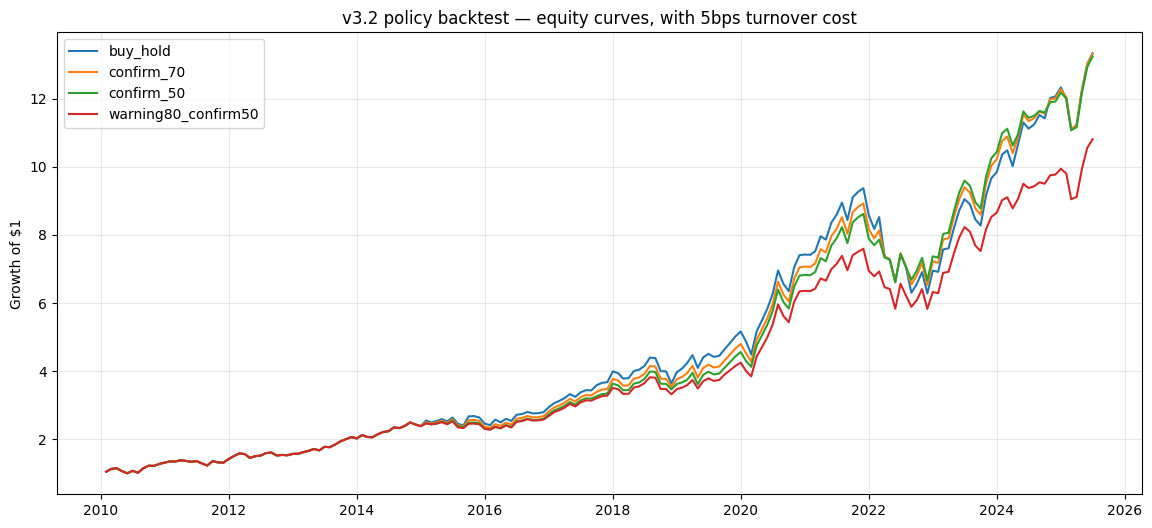


Saved:
/content/v32_policy_backtest.csv
/content/v32_policy_performance.csv


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Step 16: Portfolio backtest for v3.2 state framework
# 目标：
# 测试 v3.2 状态是否能改善组合回撤/风险收益
# ============================================================

# ===== 0. 准备状态和月度收益 =====

# ===== 0. 准备状态和月度收益 =====

bt = final_state.copy()
bt.index = pd.to_datetime(bt.index)

# 为避免和 final_state 里已有的 ret_1m 重名，这里单独命名为 ndx_ret_1m
ndx_m_close = ndx_d[['ndx_close']].resample('ME').last()
ndx_m_close['ndx_ret_1m'] = ndx_m_close['ndx_close'].pct_change()

# state at month-end t controls exposure for next month t+1
# 也就是用 t 月末状态，吃 t+1 月收益
bt['next_month_ret'] = ndx_m_close['ndx_ret_1m'].shift(-1).reindex(bt.index)

# 如果之前反复运行过，保险起见，不影响
bt = bt.dropna(subset=['next_month_ret']).copy()

print("=== Backtest data check ===")
print(f"N = {len(bt)}")
print(f"Start = {bt.index.min()}")
print(f"End = {bt.index.max()}")
print(bt[['state_v32', 'next_month_ret']].tail())

print("=== Backtest data check ===")
print(f"N = {len(bt)}")
print(f"Start = {bt.index.min()}")
print(f"End = {bt.index.max()}")
print(bt[['state_v32', 'next_month_ret']].tail())


# ===== 1. 定义几套仓位规则 =====
# exposure = 投入 QQQ/NDX 的比例，剩余部分假设现金收益 = 0
# 这是保守简化，之后可加入 T-bill return

def exposure_policy(state, policy_name):
    if policy_name == 'buy_hold':
        return 1.0

    # 只在 RED_CONFIRM 降仓
    if policy_name == 'confirm_70':
        return 0.70 if state == 'RED_CONFIRM' else 1.00

    if policy_name == 'confirm_50':
        return 0.50 if state == 'RED_CONFIRM' else 1.00

    if policy_name == 'confirm_0':
        return 0.00 if state == 'RED_CONFIRM' else 1.00

    # RED_WARNING 轻微降仓，RED_CONFIRM 明显降仓
    if policy_name == 'warning80_confirm50':
        if state == 'RED_CONFIRM':
            return 0.50
        elif state == 'RED_WARNING':
            return 0.80
        else:
            return 1.00

    if policy_name == 'warning70_confirm40':
        if state == 'RED_CONFIRM':
            return 0.40
        elif state == 'RED_WARNING':
            return 0.70
        else:
            return 1.00

    raise ValueError(f"Unknown policy: {policy_name}")


policies = [
    'buy_hold',
    'confirm_70',
    'confirm_50',
    'confirm_0',
    'warning80_confirm50',
    'warning70_confirm40',
]


# ===== 2. 生成策略收益 =====

for p in policies:
    bt[f'exposure_{p}'] = bt['state_v32'].apply(lambda s: exposure_policy(s, p))
    bt[f'ret_{p}'] = bt[f'exposure_{p}'] * bt['next_month_ret']

    # 简单交易成本：每次仓位变化收 5 bps 成本
    # 先不扣也可以；这里保留成本版本
    turnover = bt[f'exposure_{p}'].diff().abs().fillna(0)
    bt[f'ret_{p}_tcost'] = bt[f'ret_{p}'] - turnover * 0.0005


# ===== 3. 绩效函数 =====

def max_drawdown(equity):
    running_max = equity.cummax()
    dd = equity / running_max - 1
    return dd.min()

def perf_stats(ret, name):
    ret = ret.dropna()
    equity = (1 + ret).cumprod()

    years = len(ret) / 12
    cagr = equity.iloc[-1] ** (1 / years) - 1
    vol = ret.std() * np.sqrt(12)
    sharpe = cagr / vol if vol > 0 else np.nan
    mdd = max_drawdown(equity)
    calmar = cagr / abs(mdd) if mdd < 0 else np.nan

    worst_1m = ret.min()
    worst_6m = (1 + ret).rolling(6).apply(np.prod, raw=True) - 1
    worst_6m = worst_6m.min()

    return {
        'policy': name,
        'months': len(ret),
        'CAGR': cagr,
        'Vol': vol,
        'Sharpe_like': sharpe,
        'MaxDD': mdd,
        'Calmar': calmar,
        'Worst_1M': worst_1m,
        'Worst_6M': worst_6m,
        'Final_Wealth': equity.iloc[-1],
    }


rows = []

for p in policies:
    rows.append(perf_stats(bt[f'ret_{p}'], p))
    rows.append(perf_stats(bt[f'ret_{p}_tcost'], p + '_tcost'))

perf = pd.DataFrame(rows).set_index('policy')

print("\n=== Portfolio performance ===")
print((perf * 100).round(2))


# ===== 4. 状态下个月收益分布 =====

state_ret = bt.groupby('state_v32').agg(
    n=('next_month_ret', 'size'),
    avg_next_ret=('next_month_ret', 'mean'),
    median_next_ret=('next_month_ret', 'median'),
    hit_rate_positive=('next_month_ret', lambda x: (x > 0).mean()),
    worst_next_ret=('next_month_ret', 'min'),
    best_next_ret=('next_month_ret', 'max'),
)

print("\n=== Next-month return by state ===")
print(state_ret.round(4))


# ===== 5. 画 equity curves =====

fig, ax = plt.subplots(figsize=(14, 6))

for p in ['buy_hold', 'confirm_70', 'confirm_50', 'warning80_confirm50']:
    equity = (1 + bt[f'ret_{p}_tcost']).cumprod()
    ax.plot(equity.index, equity, label=p)

ax.set_title("v3.2 policy backtest — equity curves, with 5bps turnover cost")
ax.set_ylabel("Growth of $1")
ax.legend()
ax.grid(alpha=0.3)

plt.show()


# ===== 6. 保存 =====

bt.to_csv('/content/v32_policy_backtest.csv')
perf.to_csv('/content/v32_policy_performance.csv')

print("\nSaved:")
print("/content/v32_policy_backtest.csv")
print("/content/v32_policy_performance.csv")

In [53]:
import numpy as np
import pandas as pd

# ============================================================
# Step 17: Robustness check by subperiod + corrected display
# ============================================================

focus_policies = [
    'buy_hold',
    'confirm_70',
    'confirm_50',
    'confirm_0',
    'warning80_confirm50',
]

# ===== 1. 正确格式化已有 perf 表 =====

def format_perf_table(perf_df):
    out = perf_df.copy()

    pct_cols = ['CAGR', 'Vol', 'MaxDD', 'Worst_1M', 'Worst_6M']
    ratio_cols = ['Sharpe_like', 'Calmar']
    plain_cols = ['months', 'Final_Wealth']

    for c in pct_cols:
        out[c] = out[c] * 100

    # Sharpe / Calmar / months / Final_Wealth 不乘 100
    return out

perf_focus = perf.loc[
    [p + '_tcost' for p in focus_policies],
    ['months', 'CAGR', 'Vol', 'Sharpe_like', 'MaxDD', 'Calmar', 'Worst_1M', 'Worst_6M', 'Final_Wealth']
]

print("=== Corrected performance table, with 5bps turnover cost ===")
print(format_perf_table(perf_focus).round(2))


# ===== 2. 分阶段绩效 =====

periods = {
    '2010-2014 calm bull': ('2010-01-31', '2014-12-31'),
    '2015-2019 mid-cycle': ('2015-01-31', '2019-12-31'),
    '2020 COVID': ('2020-01-31', '2020-12-31'),
    '2021-2022 tech bear': ('2021-01-31', '2022-12-31'),
    '2023-2025 recent': ('2023-01-31', '2025-06-30'),
}

period_rows = []

for period_name, (start, end) in periods.items():
    sub = bt[(bt.index >= pd.Timestamp(start)) & (bt.index <= pd.Timestamp(end))].copy()

    for p in focus_policies:
        ret_col = f'ret_{p}_tcost'
        if ret_col not in sub.columns:
            continue

        m = perf_stats(sub[ret_col], p)
        m['period'] = period_name
        period_rows.append(m)

period_perf = pd.DataFrame(period_rows).set_index(['period', 'policy'])

print("\n=== Period performance, with 5bps turnover cost ===")
print(
    format_perf_table(
        period_perf[['months', 'CAGR', 'Vol', 'Sharpe_like', 'MaxDD', 'Calmar', 'Worst_1M', 'Worst_6M', 'Final_Wealth']]
    ).round(2)
)


# ===== 3. 最大回撤细节 =====

def drawdown_details(ret):
    ret = ret.dropna()
    equity = (1 + ret).cumprod()
    running_max = equity.cummax()
    dd = equity / running_max - 1

    trough_date = dd.idxmin()
    peak_date = equity.loc[:trough_date].idxmax()
    peak_value = equity.loc[peak_date]
    trough_value = equity.loc[trough_date]

    recovery = equity.loc[trough_date:][equity.loc[trough_date:] >= peak_value]
    recovery_date = recovery.index[0] if len(recovery) > 0 else pd.NaT

    return {
        'peak_date': peak_date,
        'trough_date': trough_date,
        'recovery_date': recovery_date,
        'max_dd': dd.min(),
        'peak_value': peak_value,
        'trough_value': trough_value,
        'months_to_trough': (trough_date.year - peak_date.year) * 12 + (trough_date.month - peak_date.month),
        'months_to_recovery': np.nan if pd.isna(recovery_date) else (recovery_date.year - peak_date.year) * 12 + (recovery_date.month - peak_date.month),
    }

dd_rows = []

for p in focus_policies:
    ret_col = f'ret_{p}_tcost'
    d = drawdown_details(bt[ret_col])
    d['policy'] = p
    dd_rows.append(d)

dd_table = pd.DataFrame(dd_rows).set_index('policy')

print("\n=== Max drawdown details, with 5bps turnover cost ===")
print(dd_table.round(4))


# ===== 4. 仓位暴露和换手 =====

exposure_rows = []

for p in focus_policies:
    exp_col = f'exposure_{p}'
    turnover = bt[exp_col].diff().abs().fillna(0)

    exposure_rows.append({
        'policy': p,
        'avg_exposure': bt[exp_col].mean(),
        'min_exposure': bt[exp_col].min(),
        'months_less_than_100': (bt[exp_col] < 1).sum(),
        'avg_annual_turnover': turnover.sum() / (len(bt) / 12),
        'max_single_change': turnover.max(),
    })

exposure_table = pd.DataFrame(exposure_rows).set_index('policy')

print("\n=== Exposure / turnover summary ===")
print(exposure_table.round(4))


# ===== 5. 状态暴露贡献：每个 state 对 buy-hold 累计收益的贡献 =====

state_contrib = bt.groupby('state_v32').agg(
    n=('next_month_ret', 'size'),
    avg_next_ret=('next_month_ret', 'mean'),
    cum_return=('next_month_ret', lambda x: (1 + x).prod() - 1),
    worst_next_ret=('next_month_ret', 'min'),
    positive_rate=('next_month_ret', lambda x: (x > 0).mean()),
)

print("\n=== State contribution under buy-hold next-month returns ===")
print(state_contrib.round(4))

=== Corrected performance table, with 5bps turnover cost ===
                           months   CAGR    Vol  Sharpe_like  MaxDD  Calmar  \
policy                                                                        
buy_hold_tcost                186  18.19  17.35         1.05 -32.97    0.55   
confirm_70_tcost              186  18.18  16.45         1.11 -26.88    0.68   
confirm_50_tcost              186  18.14  16.01         1.13 -23.20    0.78   
confirm_0_tcost               186  17.90  15.55         1.15 -16.84    1.06   
warning80_confirm50_tcost     186  16.60  15.42         1.08 -23.26    0.71   

                           Worst_1M  Worst_6M  Final_Wealth  
policy                                                       
buy_hold_tcost               -13.37    -29.51         13.34  
confirm_70_tcost              -9.36    -25.73         13.32  
confirm_50_tcost              -9.06    -23.20         13.24  
confirm_0_tcost               -9.06    -16.84         12.84  
warning80_con

=== Cash return check ===
              state_v32  next_month_ret  cash_next_month_ret
date                                                        
2024-07-31  RED_CONFIRM        0.010960             0.004208
2024-08-31  RED_CONFIRM        0.024831             0.003933
2024-09-30  RED_CONFIRM       -0.008488             0.003758
2024-10-31  RED_CONFIRM        0.052284             0.003683
2024-11-30  RED_CONFIRM        0.003908             0.003558
2024-12-31  RED_WARNING        0.022172             0.003508
2025-01-31  RED_CONFIRM       -0.027639             0.003517
2025-02-28      NEUTRAL       -0.076898             0.003500
2025-03-31  RED_CONFIRM        0.015176             0.003508
2025-04-30      NEUTRAL        0.090438             0.003542
2025-05-31      NEUTRAL        0.062697             0.003525
2025-06-30      NEUTRAL        0.023771             0.003542
count    186.000000
mean       0.001107
std        0.001494
min        0.000008
25%        0.000050
50%        0.000192


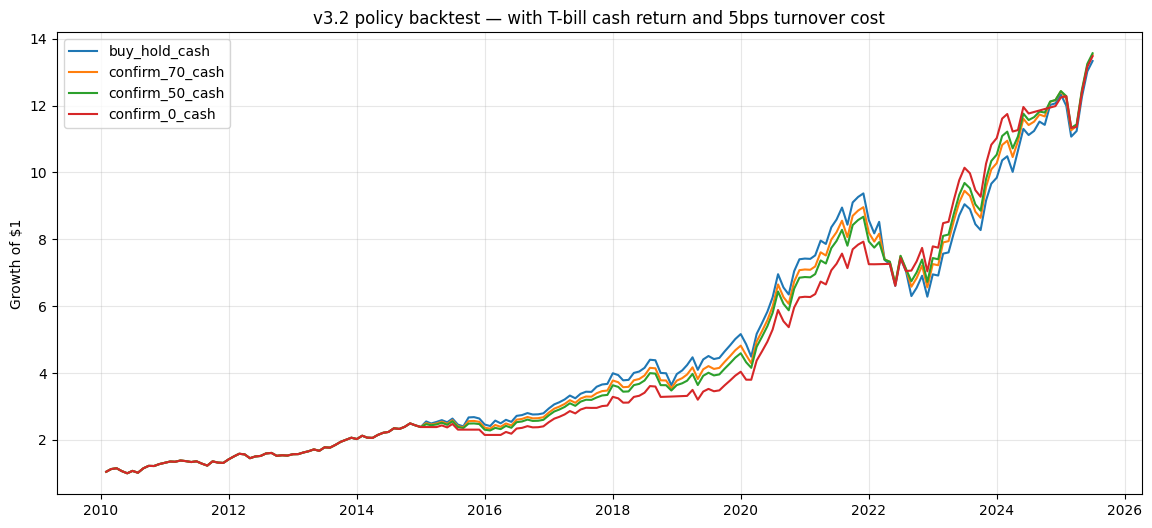


Saved:
/content/v32_policy_backtest_with_cash.csv
/content/v32_policy_performance_with_cash.csv
/content/v32_cash_vs_0cash_comparison.csv


In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Step 18: Add cash / T-bill return to defensive allocation
# 逻辑：
# portfolio return = exposure * QQQ_next_month_return
#                  + (1 - exposure) * cash_next_month_return
# ============================================================

# ===== 0. 准备 bt_rf =====

bt_rf = bt.copy()
bt_rf.index = pd.to_datetime(bt_rf.index)

# ===== 1. 拉 3-month T-bill 月度收益 =====
# 优先用 FRED 的 TB3MS：3-Month Treasury Bill, Secondary Market Rate, monthly, annualized %
# 如果你的 fred 已经在前面定义过，可以直接用
# fred = Fred(api_key=userdata.get('FRED_API_KEY'))

tb3ms = fred.get_series('TB3MS', observation_start='2000-01-01')
tb3ms = tb3ms.resample('ME').last().to_frame('tbill_3m_rate_pct')

# 年化百分比转月收益，简单近似
tb3ms['cash_ret_1m'] = tb3ms['tbill_3m_rate_pct'] / 100 / 12

bt_rf['cash_next_month_ret'] = tb3ms['cash_ret_1m'].shift(-1).reindex(bt_rf.index)

# 如果早期缺失，用 0 填充
bt_rf['cash_next_month_ret'] = bt_rf['cash_next_month_ret'].fillna(0)

print("=== Cash return check ===")
print(bt_rf[['state_v32', 'next_month_ret', 'cash_next_month_ret']].tail(12))
print(bt_rf['cash_next_month_ret'].describe().round(6))


# ===== 2. 重新计算含现金收益的策略收益 =====

focus_policies = [
    'buy_hold',
    'confirm_70',
    'confirm_50',
    'confirm_0',
    'warning80_confirm50',
]

for p in focus_policies:
    exp_col = f'exposure_{p}'

    if exp_col not in bt_rf.columns:
        raise ValueError(f"{exp_col} not found. Please run Step 16 first.")

    turnover = bt_rf[exp_col].diff().abs().fillna(0)

    bt_rf[f'ret_{p}_rf'] = (
        bt_rf[exp_col] * bt_rf['next_month_ret']
        + (1 - bt_rf[exp_col]) * bt_rf['cash_next_month_ret']
    )

    # 5 bps turnover cost
    bt_rf[f'ret_{p}_rf_tcost'] = bt_rf[f'ret_{p}_rf'] - turnover * 0.0005


# ===== 3. 绩效函数复用 =====

def max_drawdown(equity):
    running_max = equity.cummax()
    dd = equity / running_max - 1
    return dd.min()

def perf_stats(ret, name):
    ret = ret.dropna()
    equity = (1 + ret).cumprod()

    years = len(ret) / 12
    cagr = equity.iloc[-1] ** (1 / years) - 1
    vol = ret.std() * np.sqrt(12)
    sharpe = cagr / vol if vol > 0 else np.nan
    mdd = max_drawdown(equity)
    calmar = cagr / abs(mdd) if mdd < 0 else np.nan

    worst_1m = ret.min()
    worst_6m = (1 + ret).rolling(6).apply(np.prod, raw=True) - 1
    worst_6m = worst_6m.min()

    return {
        'policy': name,
        'months': len(ret),
        'CAGR': cagr,
        'Vol': vol,
        'Sharpe_like': sharpe,
        'MaxDD': mdd,
        'Calmar': calmar,
        'Worst_1M': worst_1m,
        'Worst_6M': worst_6m,
        'Final_Wealth': equity.iloc[-1],
    }

rows = []

for p in focus_policies:
    rows.append(perf_stats(bt_rf[f'ret_{p}_rf_tcost'], p + '_rf_tcost'))

perf_rf = pd.DataFrame(rows).set_index('policy')


# ===== 4. 格式化输出 =====

def format_perf_table(perf_df):
    out = perf_df.copy()
    pct_cols = ['CAGR', 'Vol', 'MaxDD', 'Worst_1M', 'Worst_6M']

    for c in pct_cols:
        out[c] = out[c] * 100

    return out

print("\n=== Performance with cash return + 5bps turnover cost ===")
print(
    format_perf_table(
        perf_rf[['months', 'CAGR', 'Vol', 'Sharpe_like', 'MaxDD', 'Calmar', 'Worst_1M', 'Worst_6M', 'Final_Wealth']]
    ).round(2)
)


# ===== 5. 和原 0% cash 版本对比 =====

compare_rows = []

for p in focus_policies:
    old_name = p + '_tcost'
    new_name = p + '_rf_tcost'

    old = perf.loc[old_name]
    new = perf_rf.loc[new_name]

    compare_rows.append({
        'policy': p,
        'old_CAGR_0cash': old['CAGR'],
        'new_CAGR_cash': new['CAGR'],
        'delta_CAGR': new['CAGR'] - old['CAGR'],

        'old_MaxDD_0cash': old['MaxDD'],
        'new_MaxDD_cash': new['MaxDD'],
        'delta_MaxDD': new['MaxDD'] - old['MaxDD'],

        'old_Final_Wealth': old['Final_Wealth'],
        'new_Final_Wealth': new['Final_Wealth'],
        'delta_Final_Wealth': new['Final_Wealth'] - old['Final_Wealth'],
    })

compare_rf = pd.DataFrame(compare_rows).set_index('policy')

print("\n=== 0% cash vs T-bill cash comparison ===")
display_compare = compare_rf.copy()

for c in ['old_CAGR_0cash', 'new_CAGR_cash', 'delta_CAGR',
          'old_MaxDD_0cash', 'new_MaxDD_cash', 'delta_MaxDD']:
    display_compare[c] = display_compare[c] * 100

print(display_compare.round(2))


# ===== 6. 画 equity curves =====

fig, ax = plt.subplots(figsize=(14, 6))

for p in ['buy_hold', 'confirm_70', 'confirm_50', 'confirm_0']:
    equity = (1 + bt_rf[f'ret_{p}_rf_tcost']).cumprod()
    ax.plot(equity.index, equity, label=p + '_cash')

ax.set_title("v3.2 policy backtest — with T-bill cash return and 5bps turnover cost")
ax.set_ylabel("Growth of $1")
ax.legend()
ax.grid(alpha=0.3)

plt.show()


# ===== 7. 保存 =====

bt_rf.to_csv('/content/v32_policy_backtest_with_cash.csv')
perf_rf.to_csv('/content/v32_policy_performance_with_cash.csv')
compare_rf.to_csv('/content/v32_cash_vs_0cash_comparison.csv')

print("\nSaved:")
print("/content/v32_policy_backtest_with_cash.csv")
print("/content/v32_policy_performance_with_cash.csv")
print("/content/v32_cash_vs_0cash_comparison.csv")

=== RED_CONFIRM exposure sensitivity ===
                 red_confirm_exposure  months   CAGR    Vol  Sharpe_like  \
policy                                                                     
red_confirm_0                     0.0     186  18.27  15.52         1.18   
red_confirm_10                    0.1     186  18.30  15.54         1.18   
red_confirm_20                    0.2     186  18.31  15.60         1.17   
red_confirm_30                    0.3     186  18.32  15.70         1.17   
red_confirm_40                    0.4     186  18.33  15.83         1.16   
red_confirm_50                    0.5     186  18.32  16.00         1.15   
red_confirm_60                    0.6     186  18.31  16.20         1.13   
red_confirm_70                    0.7     186  18.29  16.44         1.11   
red_confirm_80                    0.8     186  18.26  16.71         1.09   
red_confirm_90                    0.9     186  18.23  17.02         1.07   
red_confirm_100                   1.0     186  

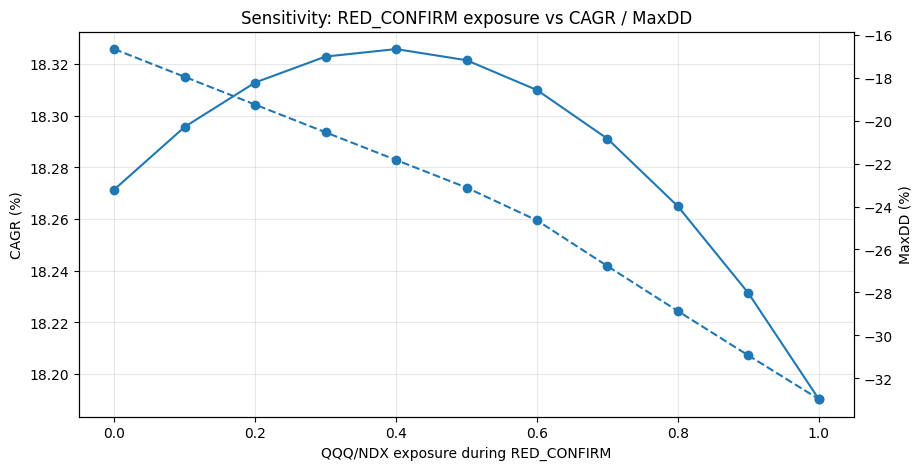


Saved: /content/v32_red_confirm_exposure_sensitivity.csv


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Step 19: RED_CONFIRM exposure sensitivity
# 测试 RED_CONFIRM 时仓位从 0% 到 100% 的连续变化
# 其余状态保持 100% QQQ/NDX
# ============================================================

bt_sens = bt_rf.copy()

exposure_grid = np.arange(0.0, 1.01, 0.1)

rows = []

for red_exp in exposure_grid:
    policy_name = f"red_confirm_{int(red_exp*100)}"

    bt_sens[f'exposure_{policy_name}'] = 1.0
    bt_sens.loc[
        bt_sens['state_v32'] == 'RED_CONFIRM',
        f'exposure_{policy_name}'
    ] = red_exp

    turnover = bt_sens[f'exposure_{policy_name}'].diff().abs().fillna(0)

    bt_sens[f'ret_{policy_name}'] = (
        bt_sens[f'exposure_{policy_name}'] * bt_sens['next_month_ret']
        + (1 - bt_sens[f'exposure_{policy_name}']) * bt_sens['cash_next_month_ret']
        - turnover * 0.0005
    )

    m = perf_stats(bt_sens[f'ret_{policy_name}'], policy_name)
    m['red_confirm_exposure'] = red_exp
    rows.append(m)

sens_perf = pd.DataFrame(rows).set_index('policy')

# 格式化显示
display_sens = sens_perf.copy()
for c in ['CAGR', 'Vol', 'MaxDD', 'Worst_1M', 'Worst_6M']:
    display_sens[c] = display_sens[c] * 100

print("=== RED_CONFIRM exposure sensitivity ===")
print(
    display_sens[
        ['red_confirm_exposure', 'months', 'CAGR', 'Vol', 'Sharpe_like',
         'MaxDD', 'Calmar', 'Worst_1M', 'Worst_6M', 'Final_Wealth']
    ].round(2)
)

# 画图：CAGR vs MaxDD
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    sens_perf['red_confirm_exposure'],
    sens_perf['CAGR'] * 100,
    marker='o',
    label='CAGR (%)'
)
ax1.set_xlabel('QQQ/NDX exposure during RED_CONFIRM')
ax1.set_ylabel('CAGR (%)')

ax2 = ax1.twinx()
ax2.plot(
    sens_perf['red_confirm_exposure'],
    sens_perf['MaxDD'] * 100,
    marker='o',
    linestyle='--',
    label='MaxDD (%)'
)
ax2.set_ylabel('MaxDD (%)')

ax1.set_title('Sensitivity: RED_CONFIRM exposure vs CAGR / MaxDD')
ax1.grid(alpha=0.3)

plt.show()

# 保存
sens_perf.to_csv('/content/v32_red_confirm_exposure_sensitivity.csv')
print("\nSaved: /content/v32_red_confirm_exposure_sensitivity.csv")

In [56]:
import numpy as np
import pandas as pd

# ============================================================
# Step 20: Rule threshold robustness test
# 固定 RED_CONFIRM exposure = 50%
# 测试 M1/M2 quantile 和 vol_ratio confirmation 阈值是否稳健
# ============================================================

# ===== 0. 准备基础数据 =====

robust = pd.DataFrame(index=wf_action.index)

robust['m1_p_raw'] = wf_debug['p_raw']
robust['m2_p_raw'] = wf_action['p_raw']
robust['label_current_15'] = wf_action['label']

robust = robust.join(
    price_stage[
        [
            'ret_1m',
            'ret_3m',
            'ret_6m',
            'dd_from_6m_high',
            'dd_from_12m_high',
            'vol_3m',
            'vol_ratio_3m_12m',
        ]
    ],
    how='left'
)

robust = robust.join(
    features_v2[
        [
            'cape_z',
            'dist_200dma',
            'tsmom_12m',
            'yc_10y3m',
            'cfnai_ma3',
            'bb_spread',
        ]
    ],
    how='left'
)

# 加入回测收益
robust = robust.join(
    bt_rf[['next_month_ret', 'cash_next_month_ret']],
    how='left'
)

robust = robust.dropna().copy()

print("=== Robustness base data check ===")
print(f"N = {len(robust)}")
print(f"Start = {robust.index.min()}")
print(f"End = {robust.index.max()}")
print(f"Base rate = {robust['label_current_15'].mean():.2%}")


# ===== 1. 绩效函数 =====

def max_drawdown(equity):
    running_max = equity.cummax()
    dd = equity / running_max - 1
    return dd.min()

def perf_stats_simple(ret):
    ret = ret.dropna()
    equity = (1 + ret).cumprod()

    years = len(ret) / 12
    cagr = equity.iloc[-1] ** (1 / years) - 1
    vol = ret.std() * np.sqrt(12)
    sharpe = cagr / vol if vol > 0 else np.nan
    mdd = max_drawdown(equity)
    calmar = cagr / abs(mdd) if mdd < 0 else np.nan
    worst_6m = ((1 + ret).rolling(6).apply(np.prod, raw=True) - 1).min()

    return {
        'months': len(ret),
        'CAGR': cagr,
        'Vol': vol,
        'Sharpe_like': sharpe,
        'MaxDD': mdd,
        'Calmar': calmar,
        'Worst_6M': worst_6m,
        'Final_Wealth': equity.iloc[-1],
    }


# ===== 2. Online state generator =====

def generate_online_states(
    data,
    m1_q=0.80,
    m2_safe_q=0.30,
    m2_min_q=0.30,
    vol_confirm_th=1.00,
    min_history=60,
):
    rows = []

    for i, date in enumerate(data.index):
        hist = data.iloc[:i]

        if len(hist) < min_history:
            rows.append({
                'date': date,
                'state': 'WARMUP',
                'm1_th': np.nan,
                'm2_safe_th': np.nan,
                'm2_min_th': np.nan,
            })
            continue

        m1_th = hist['m1_p_raw'].quantile(m1_q)
        m2_safe_th = hist['m2_p_raw'].quantile(m2_safe_q)
        m2_min_th = hist['m2_p_raw'].quantile(m2_min_q)

        row = data.loc[date]

        macro_shock = (
            (row['cfnai_ma3'] <= -1.0) |
            (row['vol_3m'] >= 0.35)
        )

        state = 'NEUTRAL'

        if row['m2_p_raw'] <= m2_safe_th:
            state = 'GREEN_SAFE'

        red_warning = (
            (row['m1_p_raw'] >= m1_th) and
            (row['m2_p_raw'] >= m2_min_th) and
            (not macro_shock)
        )

        if red_warning:
            state = 'RED_WARNING'

        if red_warning and (row['vol_ratio_3m_12m'] >= vol_confirm_th):
            state = 'RED_CONFIRM'

        rows.append({
            'date': date,
            'state': state,
            'm1_th': m1_th,
            'm2_safe_th': m2_safe_th,
            'm2_min_th': m2_min_th,
        })

    return pd.DataFrame(rows).set_index('date')


# ===== 3. Grid search =====

m1_grid = [0.75, 0.80, 0.85]
m2_grid = [0.25, 0.30, 0.35]
vol_grid = [0.90, 1.00, 1.10]

result_rows = []

for m1_q in m1_grid:
    for m2_q in m2_grid:
        for vol_th in vol_grid:

            states = generate_online_states(
                robust,
                m1_q=m1_q,
                m2_safe_q=m2_q,
                m2_min_q=m2_q,
                vol_confirm_th=vol_th,
                min_history=60,
            )

            tmp = robust.join(states, how='left')
            tmp = tmp[tmp['state'] != 'WARMUP'].copy()

            # RED_CONFIRM exposure = 50%，其他状态 100%
            tmp['exposure'] = 1.0
            tmp.loc[tmp['state'] == 'RED_CONFIRM', 'exposure'] = 0.50

            turnover = tmp['exposure'].diff().abs().fillna(0)

            tmp['strategy_ret'] = (
                tmp['exposure'] * tmp['next_month_ret']
                + (1 - tmp['exposure']) * tmp['cash_next_month_ret']
                - turnover * 0.0005
            )

            perf_m = perf_stats_simple(tmp['strategy_ret'])

            base_rate = tmp['label_current_15'].mean()

            state_counts = tmp.groupby('state')['label_current_15'].agg(['size', 'mean', 'sum'])

            def get_state_stat(state, col, default=np.nan):
                if state in state_counts.index:
                    return state_counts.loc[state, col]
                return default

            result_rows.append({
                'm1_q': m1_q,
                'm2_q': m2_q,
                'vol_confirm_th': vol_th,

                'green_n': get_state_stat('GREEN_SAFE', 'size', 0),
                'green_hit_rate': get_state_stat('GREEN_SAFE', 'mean'),
                'red_warning_n': get_state_stat('RED_WARNING', 'size', 0),
                'red_warning_hit_rate': get_state_stat('RED_WARNING', 'mean'),
                'red_confirm_n': get_state_stat('RED_CONFIRM', 'size', 0),
                'red_confirm_hit_rate': get_state_stat('RED_CONFIRM', 'mean'),
                'red_confirm_lift': get_state_stat('RED_CONFIRM', 'mean') / base_rate if get_state_stat('RED_CONFIRM', 'size', 0) > 0 else np.nan,

                **perf_m
            })

robust_table = pd.DataFrame(result_rows)


# ===== 4. 输出总体结果 =====

display_cols = [
    'm1_q', 'm2_q', 'vol_confirm_th',
    'green_n', 'green_hit_rate',
    'red_confirm_n', 'red_confirm_hit_rate', 'red_confirm_lift',
    'CAGR', 'Vol', 'Sharpe_like', 'MaxDD', 'Calmar', 'Worst_6M', 'Final_Wealth'
]

display_robust = robust_table[display_cols].copy()

for c in ['green_hit_rate', 'red_confirm_hit_rate', 'CAGR', 'Vol', 'MaxDD', 'Worst_6M']:
    display_robust[c] = display_robust[c] * 100

print("=== Threshold robustness: all combinations ===")
print(display_robust.round(3).sort_values(['Calmar', 'CAGR'], ascending=[False, False]))


# ===== 5. 看默认规则附近 =====

default_neighbors = robust_table[
    (robust_table['m1_q'].isin([0.75, 0.80, 0.85])) &
    (robust_table['m2_q'].isin([0.25, 0.30, 0.35])) &
    (robust_table['vol_confirm_th'].isin([0.90, 1.00, 1.10]))
].copy()

display_neighbors = default_neighbors[display_cols].copy()

for c in ['green_hit_rate', 'red_confirm_hit_rate', 'CAGR', 'Vol', 'MaxDD', 'Worst_6M']:
    display_neighbors[c] = display_neighbors[c] * 100

print("\n=== Default-neighborhood robustness table ===")
print(display_neighbors.round(3).sort_values(['m1_q', 'm2_q', 'vol_confirm_th']))


# ===== 6. 稳健性摘要 =====

valid = robust_table[
    (robust_table['green_n'] >= 30) &
    (robust_table['red_confirm_n'] >= 15)
].copy()

summary_stats = valid[
    ['CAGR', 'MaxDD', 'Calmar', 'red_confirm_hit_rate', 'green_hit_rate', 'Final_Wealth']
].describe()

display_summary = summary_stats.copy()

for c in ['CAGR', 'MaxDD', 'red_confirm_hit_rate', 'green_hit_rate']:
    display_summary[c] = display_summary[c] * 100

print("\n=== Robustness summary for valid rules ===")
print(display_summary.round(3))


# ===== 7. 保存 =====

robust_table.to_csv('/content/v32_threshold_robustness.csv')
print("\nSaved: /content/v32_threshold_robustness.csv")

=== Robustness base data check ===
N = 186
Start = 2010-01-31 00:00:00
End = 2025-06-30 00:00:00
Base rate = 13.98%
=== Threshold robustness: all combinations ===
    m1_q  m2_q  vol_confirm_th  green_n  green_hit_rate  red_confirm_n  \
19  0.85  0.25             1.0        3             0.0             34   
22  0.85  0.30             1.0        3             0.0             34   
25  0.85  0.35             1.0        3             0.0             34   
10  0.80  0.25             1.0        3             0.0             35   
13  0.80  0.30             1.0        3             0.0             35   
16  0.80  0.35             1.0        3             0.0             35   
1   0.75  0.25             1.0        3             0.0             37   
4   0.75  0.30             1.0        3             0.0             37   
7   0.75  0.35             1.0        3             0.0             37   
18  0.85  0.25             0.9        3             0.0             47   
21  0.85  0.30         

In [57]:
import numpy as np
import pandas as pd

# ============================================================
# Step 20b: Corrected rule threshold robustness test
# 修复点：
# 1. 用完整 2005–2025 的 wf_action / wf_debug 计算 online threshold
# 2. 不从 bt_rf 起步，避免 2010 后再 warmup 一次
# 3. 仍然固定 RED_CONFIRM exposure = 50%
# ============================================================

# ===== 0. 准备完整 robust_full 数据：从 2005 起 =====

robust_full = pd.DataFrame(index=wf_action.index)
robust_full.index = pd.to_datetime(robust_full.index)

robust_full['m1_p_raw'] = wf_debug['p_raw']
robust_full['m2_p_raw'] = wf_action['p_raw']
robust_full['label_current_15'] = wf_action['label']

# 加入 price-stage
robust_full = robust_full.join(
    price_stage[
        [
            'ret_1m',
            'ret_3m',
            'ret_6m',
            'dd_from_6m_high',
            'dd_from_12m_high',
            'vol_3m',
            'vol_ratio_3m_12m',
        ]
    ],
    how='left'
)

# 加入基础特征
robust_full = robust_full.join(
    features_v2[
        [
            'cape_z',
            'dist_200dma',
            'tsmom_12m',
            'yc_10y3m',
            'cfnai_ma3',
            'bb_spread',
        ]
    ],
    how='left'
)

# 重新生成 next_month_ret，不依赖 bt_rf
ndx_m_close = ndx_d[['ndx_close']].resample('ME').last()
ndx_m_close['ndx_ret_1m'] = ndx_m_close['ndx_close'].pct_change()
robust_full['next_month_ret'] = ndx_m_close['ndx_ret_1m'].shift(-1).reindex(robust_full.index)

# 重新生成 cash return，如果 tb3ms 已经存在就复用；否则从 FRED 拉
try:
    tb3ms
except NameError:
    tb3ms = fred.get_series('TB3MS', observation_start='2000-01-01')
    tb3ms = tb3ms.resample('ME').last().to_frame('tbill_3m_rate_pct')
    tb3ms['cash_ret_1m'] = tb3ms['tbill_3m_rate_pct'] / 100 / 12

robust_full['cash_next_month_ret'] = tb3ms['cash_ret_1m'].shift(-1).reindex(robust_full.index)
robust_full['cash_next_month_ret'] = robust_full['cash_next_month_ret'].fillna(0)

# 只去掉必要缺失
needed_cols = [
    'm1_p_raw',
    'm2_p_raw',
    'label_current_15',
    'next_month_ret',
    'cash_next_month_ret',
    'vol_ratio_3m_12m',
    'cfnai_ma3',
    'vol_3m',
]

robust_full = robust_full.dropna(subset=needed_cols).copy()

print("=== Corrected robustness full data check ===")
print(f"N = {len(robust_full)}")
print(f"Start = {robust_full.index.min()}")
print(f"End = {robust_full.index.max()}")
print(f"Base rate full = {robust_full['label_current_15'].mean():.2%}")


# ===== 1. 绩效函数 =====

def max_drawdown(equity):
    running_max = equity.cummax()
    dd = equity / running_max - 1
    return dd.min()

def perf_stats_simple(ret):
    ret = ret.dropna()
    equity = (1 + ret).cumprod()

    years = len(ret) / 12
    cagr = equity.iloc[-1] ** (1 / years) - 1
    vol = ret.std() * np.sqrt(12)
    sharpe = cagr / vol if vol > 0 else np.nan
    mdd = max_drawdown(equity)
    calmar = cagr / abs(mdd) if mdd < 0 else np.nan
    worst_6m = ((1 + ret).rolling(6).apply(np.prod, raw=True) - 1).min()

    return {
        'months': len(ret),
        'CAGR': cagr,
        'Vol': vol,
        'Sharpe_like': sharpe,
        'MaxDD': mdd,
        'Calmar': calmar,
        'Worst_6M': worst_6m,
        'Final_Wealth': equity.iloc[-1],
    }


# ===== 2. Online state generator =====

def generate_online_states(
    data,
    m1_q=0.80,
    m2_safe_q=0.30,
    m2_min_q=0.30,
    vol_confirm_th=1.00,
    min_history=60,
):
    rows = []

    for i, date in enumerate(data.index):
        hist = data.iloc[:i]

        if len(hist) < min_history:
            rows.append({
                'date': date,
                'state': 'WARMUP',
                'm1_th': np.nan,
                'm2_safe_th': np.nan,
                'm2_min_th': np.nan,
            })
            continue

        m1_th = hist['m1_p_raw'].quantile(m1_q)
        m2_safe_th = hist['m2_p_raw'].quantile(m2_safe_q)
        m2_min_th = hist['m2_p_raw'].quantile(m2_min_q)

        row = data.loc[date]

        macro_shock = (
            (row['cfnai_ma3'] <= -1.0) |
            (row['vol_3m'] >= 0.35)
        )

        state = 'NEUTRAL'

        if row['m2_p_raw'] <= m2_safe_th:
            state = 'GREEN_SAFE'

        red_warning = (
            (row['m1_p_raw'] >= m1_th) and
            (row['m2_p_raw'] >= m2_min_th) and
            (not macro_shock)
        )

        if red_warning:
            state = 'RED_WARNING'

        if red_warning and (row['vol_ratio_3m_12m'] >= vol_confirm_th):
            state = 'RED_CONFIRM'

        rows.append({
            'date': date,
            'state': state,
            'm1_th': m1_th,
            'm2_safe_th': m2_safe_th,
            'm2_min_th': m2_min_th,
        })

    return pd.DataFrame(rows).set_index('date')


# ===== 3. Grid search =====

m1_grid = [0.75, 0.80, 0.85]
m2_grid = [0.25, 0.30, 0.35]
vol_grid = [0.90, 1.00, 1.10]

result_rows = []

for m1_q in m1_grid:
    for m2_q in m2_grid:
        for vol_th in vol_grid:

            states = generate_online_states(
                robust_full,
                m1_q=m1_q,
                m2_safe_q=m2_q,
                m2_min_q=m2_q,
                vol_confirm_th=vol_th,
                min_history=60,
            )

            tmp = robust_full.join(states, how='left')
            tmp = tmp[tmp['state'] != 'WARMUP'].copy()

            # RED_CONFIRM exposure = 50%，其他状态 100%
            tmp['exposure'] = 1.0
            tmp.loc[tmp['state'] == 'RED_CONFIRM', 'exposure'] = 0.50

            turnover = tmp['exposure'].diff().abs().fillna(0)

            tmp['strategy_ret'] = (
                tmp['exposure'] * tmp['next_month_ret']
                + (1 - tmp['exposure']) * tmp['cash_next_month_ret']
                - turnover * 0.0005
            )

            perf_m = perf_stats_simple(tmp['strategy_ret'])

            base_rate = tmp['label_current_15'].mean()
            state_counts = tmp.groupby('state')['label_current_15'].agg(['size', 'mean', 'sum'])

            def get_state_stat(state, col, default=np.nan):
                if state in state_counts.index:
                    return state_counts.loc[state, col]
                return default

            result_rows.append({
                'm1_q': m1_q,
                'm2_q': m2_q,
                'vol_confirm_th': vol_th,

                'eval_start': tmp.index.min(),
                'eval_end': tmp.index.max(),
                'eval_n': len(tmp),
                'base_rate': base_rate,

                'green_n': get_state_stat('GREEN_SAFE', 'size', 0),
                'green_hit_rate': get_state_stat('GREEN_SAFE', 'mean'),
                'red_warning_n': get_state_stat('RED_WARNING', 'size', 0),
                'red_warning_hit_rate': get_state_stat('RED_WARNING', 'mean'),
                'red_confirm_n': get_state_stat('RED_CONFIRM', 'size', 0),
                'red_confirm_hit_rate': get_state_stat('RED_CONFIRM', 'mean'),
                'red_confirm_lift': (
                    get_state_stat('RED_CONFIRM', 'mean') / base_rate
                    if get_state_stat('RED_CONFIRM', 'size', 0) > 0
                    else np.nan
                ),

                **perf_m
            })

robust_table2 = pd.DataFrame(result_rows)


# ===== 4. 输出总体结果 =====

display_cols = [
    'm1_q', 'm2_q', 'vol_confirm_th',
    'eval_n', 'base_rate',
    'green_n', 'green_hit_rate',
    'red_confirm_n', 'red_confirm_hit_rate', 'red_confirm_lift',
    'CAGR', 'Vol', 'Sharpe_like', 'MaxDD', 'Calmar', 'Worst_6M', 'Final_Wealth'
]

display_robust2 = robust_table2[display_cols].copy()

for c in ['base_rate', 'green_hit_rate', 'red_confirm_hit_rate', 'CAGR', 'Vol', 'MaxDD', 'Worst_6M']:
    display_robust2[c] = display_robust2[c] * 100

print("=== Corrected threshold robustness: all combinations ===")
print(
    display_robust2
    .round(3)
    .sort_values(['Calmar', 'CAGR'], ascending=[False, False])
)


# ===== 5. 默认规则附近 =====

display_neighbors2 = robust_table2[display_cols].copy()

for c in ['base_rate', 'green_hit_rate', 'red_confirm_hit_rate', 'CAGR', 'Vol', 'MaxDD', 'Worst_6M']:
    display_neighbors2[c] = display_neighbors2[c] * 100

print("\n=== Corrected default-neighborhood robustness table ===")
print(
    display_neighbors2
    .round(3)
    .sort_values(['m1_q', 'm2_q', 'vol_confirm_th'])
)


# ===== 6. 稳健性摘要 =====

valid2 = robust_table2[
    (robust_table2['green_n'] >= 30) &
    (robust_table2['red_confirm_n'] >= 15)
].copy()

summary_stats2 = valid2[
    ['CAGR', 'MaxDD', 'Calmar', 'red_confirm_hit_rate', 'green_hit_rate', 'Final_Wealth']
].describe()

display_summary2 = summary_stats2.copy()

for c in ['CAGR', 'MaxDD', 'red_confirm_hit_rate', 'green_hit_rate']:
    display_summary2[c] = display_summary2[c] * 100

print("\n=== Corrected robustness summary for valid rules ===")
print(display_summary2.round(3))


# ===== 7. 默认规则单独输出 =====

default_rule = robust_table2[
    (robust_table2['m1_q'] == 0.80) &
    (robust_table2['m2_q'] == 0.30) &
    (robust_table2['vol_confirm_th'] == 1.00)
]

print("\n=== Corrected default rule ===")
display_default = default_rule[display_cols].copy()

for c in ['base_rate', 'green_hit_rate', 'red_confirm_hit_rate', 'CAGR', 'Vol', 'MaxDD', 'Worst_6M']:
    display_default[c] = display_default[c] * 100

print(display_default.round(3))


# ===== 8. 保存 =====

robust_table2.to_csv('/content/v32_threshold_robustness_corrected.csv')
print("\nSaved: /content/v32_threshold_robustness_corrected.csv")

=== Corrected robustness full data check ===
N = 246
Start = 2005-01-31 00:00:00
End = 2025-06-30 00:00:00
Base rate full = 15.45%
=== Corrected threshold robustness: all combinations ===
    m1_q  m2_q  vol_confirm_th  eval_n  base_rate  green_n  green_hit_rate  \
1   0.75  0.25             1.0     186     13.978       35           2.857   
4   0.75  0.30             1.0     186     13.978       42           2.381   
7   0.75  0.35             1.0     186     13.978       48           2.083   
10  0.80  0.25             1.0     186     13.978       35           2.857   
13  0.80  0.30             1.0     186     13.978       42           2.381   
16  0.80  0.35             1.0     186     13.978       48           2.083   
0   0.75  0.25             0.9     186     13.978       35           2.857   
3   0.75  0.30             0.9     186     13.978       42           2.381   
6   0.75  0.35             0.9     186     13.978       48           2.083   
9   0.80  0.25             0.9  